**Author:** Tianqi Shen & Runze Shi & GPT-4o

**Date:** 17 June 2026

# Empirical Evidence for Muon as an Early Exploration Optimizer
## LLM-pretraining Experiments

We perform empirical experiments in a language model pre-training setting using a 250M-parameter LLaMA-style decoder-only Transformer trained from scratch, rather than a pretrained LLaMA checkpoint. We use the GPT-2 tokenizer and OpenWebText2 dataset for pre-training. All runs are trained for 4k steps under the same training budget. We compare several Muon baselines, including Muon with cosine, linear, and $\mathtt{cos\_inf}$ learning-rate (LR) schedules, against two-stage runs that first train with Muon without LR decay and then switching to AdamW. Experimental setting adapted from https://github.com/epfml/schedules-and-scaling, which is an extension of nanoGPT.

In [1]:
%matplotlib inline
#import matplotlib_inline   # setup output image format, do not use 'svg' if need 'pdf' output
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import matplotlib
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle, ConnectionPatch

### Define colors for plotting

In [2]:
colors = {  # Algorithms to plot + their colors
    "muon": "#ff244f",
    "muon-cos_inf": "#a50f15",
    "muon-linear": "#fb6a4a",
    "muon-cosine": "#fcae91",
    "muon->adamw-lr1e-3": "#006d2c",
    "muon->adamw-lr1.5e-3": "#41ab5d",
    "muon->adamw-cos_inf-lr1.5e-3": "#a50f15",
    "muon->adamw-linear-lr1.5e-3": "#fb6a4a",
    "muon->adamw-cosine-lr1.5e-3": "#fcae91",
    "muon->adamw-lr5e-5": "#41ab5d",
    "muon->adamw-cos_inf-lr5e-5": "#a50f15",
    "muon->adamw-linear-lr5e-5": "#fb6a4a",
    "muon->adamw-cosine-lr5e-5": "#fcae91",
    "muon->adamw-lr1.35e-4": "#41ab5d",
    "muon->adamw-cos_inf-lr1.35e-4": "#a50f15",
    "muon->adamw-linear-lr1.35e-4": "#fb6a4a",
    "muon->adamw-cosine-lr1.35e-4": "#fcae91",
    "muon->adamw-lr8e-4": "#41ab5d",
    "muon->adamw-cos_inf-lr8e-4": "#a50f15",
    "muon->adamw-linear-lr8e-4": "#fb6a4a",
    "muon->adamw-cosine-lr8e-4": "#fcae91",
}

switch_color = "#4B0082"

col_map_train = {  # Column names in the CSV
    "muon": "muon - train/loss",
    "muon-cos_inf": "muon-cos_inf - train/loss",
    "muon-linear": "muon-linear - train/loss",
    "muon-cosine": "muon-cosine - train/loss",
    "muon800": "muon800 - train/loss",
    "muon1000": "muon1000 - train/loss",
    "muon1500": "muon1500 - train/loss",
    "muon2000": "muon2000 - train/loss",
    "muon3000": "muon3000 - train/loss",
    "muon3750": "muon3750 - train/loss",
    "muon->adamw-lr1e-3": "muon+adamw--lr1e-3 - train/loss",
    "muon->adamw-lr1.5e-3": "muon+adamw--lr1.5e-3 - train/loss",
    "muon->adamw-cos_inf-lr1.5e-3": "muon+adamwcos_inf--lr1.5e-3 - train/loss",
    "muon->adamw-linear-lr1.5e-3": "muon+adamwlinear--lr1.5e-3 - train/loss",
    "muon->adamw-cosine-lr1.5e-3": "muon+adamwcos--lr1.5e-3 - train/loss",
    "muon->adamw-lr5e-5": "muon+adamw--lr5e-5 - train/loss",
    "muon->adamw-cos_inf-lr5e-5": "muon+adamwcos_inf--lr5e-5 - train/loss",
    "muon->adamw-linear-lr5e-5": "muon+adamwlinear--lr5e-5 - train/loss",
    "muon->adamw-cosine-lr5e-5": "muon+adamwcos--lr5e-5 - train/loss",
    "muon->adamw-lr1.35e-4": "muon+adamw--lr1.35e-4 - train/loss",
    "muon->adamw-cos_inf-lr1.35e-4": "muon+adamwcos_inf--lr1.35e-4 - train/loss",
    "muon->adamw-linear-lr1.35e-4": "muon+adamwlinear--lr1.35e-4 - train/loss",
    "muon->adamw-cosine-lr1.35e-4": "muon+adamwcos--lr1.35e-4 - train/loss",
    "muon->adamw-lr8e-4": "muon+adamw--lr8e-4 - train/loss",
    "muon->adamw-cos_inf-lr8e-4": "muon+adamwcos_inf--lr8e-4 - train/loss",
    "muon->adamw-linear-lr8e-4": "muon+adamwlinear--lr8e-4 - train/loss",
    "muon->adamw-cosine-lr8e-4": "muon+adamwcos--lr8e-4 - train/loss",
}

col_map_val = {  # Column names in the CSV
    "muon": "muon - val/loss",
    "muon-cos_inf": "muon-cos_inf - val/loss",
    "muon-linear": "muon-linear - val/loss",
    "muon-cosine": "muon-cosine - val/loss",
    "muon800": "muon800 - val/loss",
    "muon1000": "muon1000 - val/loss",
    "muon1500": "muon1500 - val/loss",
    "muon2000": "muon2000 - val/loss",
    "muon3000": "muon3000 - val/loss",
    "muon3750": "muon3750 - val/loss",
    "muon->adamw-lr1e-3": "muon+adamw--lr1e-3 - val/loss",
    "muon->adamw-lr1.5e-3": "muon+adamw--lr1.5e-3 - val/loss",
    "muon->adamw-cos_inf-lr1.5e-3": "muon+adamwcos_inf--lr1.5e-3 - val/loss",
    "muon->adamw-linear-lr1.5e-3": "muon+adamwlinear--lr1.5e-3 - val/loss",
    "muon->adamw-cosine-lr1.5e-3": "muon+adamwcos--lr1.5e-3 - val/loss",
    "muon->adamw-lr5e-5": "muon+adamw--lr5e-5 - val/loss",
    "muon->adamw-cos_inf-lr5e-5": "muon+adamwcos_inf--lr5e-5 - val/loss",
    "muon->adamw-linear-lr5e-5": "muon+adamwlinear--lr5e-5 - val/loss",
    "muon->adamw-cosine-lr5e-5": "muon+adamwcos--lr5e-5 - val/loss",
    "muon->adamw-lr1.35e-4": "muon+adamw--lr1.35e-4 - val/loss",
    "muon->adamw-cos_inf-lr1.35e-4": "muon+adamwcos_inf--lr1.35e-4 - val/loss",
    "muon->adamw-linear-lr1.35e-4": "muon+adamwlinear--lr1.35e-4 - val/loss",
    "muon->adamw-cosine-lr1.35e-4": "muon+adamwcos--lr1.35e-4 - val/loss",
    "muon->adamw-lr8e-4": "muon+adamw--lr8e-4 - val/loss",
    "muon->adamw-cos_inf-lr8e-4": "muon+adamwcos_inf--lr8e-4 - val/loss",
    "muon->adamw-linear-lr8e-4": "muon+adamwlinear--lr8e-4 - val/loss",
    "muon->adamw-cosine-lr8e-4": "muon+adamwcos--lr8e-4 - val/loss",
}

### Functional helpers for obtaining curve data

In [3]:
# Helper: load a single curve (x, y)
def get_curve(df, x_col, col_name: str):
    data = df[[x_col, col_name]].copy()
    data[col_name] = pd.to_numeric(data[col_name], errors="coerce")
    data = data.dropna()
    data = data.sort_values(x_col)
    return data[x_col].to_numpy(), data[col_name].to_numpy()

# Build a hybrid curve by concatenating: (muon1000 up to switch_iter) + (adamw curve from switch_iter onward)
# If there is a duplicated point at switch_iter, we must keep only one.
# keep="post" means: keep the post-switch (adamw) value at the duplicated iteration.
def get_hybrid_curve(df, x_col, muon_name: str, adamw_col: str, switch_iter: int, mode: str, keep="post"):
    if mode == "train":
        col_map = col_map_train
    else:
        col_map = col_map_val
    
    pre = df[[x_col, col_map[muon_name]]].copy()
    pre[col_map[muon_name]] = pd.to_numeric(pre[col_map[muon_name]], errors="coerce")
    pre = pre.dropna()
    pre = pre[pre[x_col] <= switch_iter]

    post = df[[x_col, adamw_col]].copy()
    post[adamw_col] = pd.to_numeric(post[adamw_col], errors="coerce")
    post = post.dropna()
    post = post[post[x_col] >= switch_iter]

    # Rename both to a common column name so we can concat them easily
    pre = pre.rename(columns={col_map[muon_name]: "loss"})
    post = post.rename(columns={adamw_col: "loss"})

    combo = pd.concat([pre, post], ignore_index=True)
    combo = combo.sort_values(x_col)

    # Remove duplicated iterations created by concatenation at the switch point
    if keep == "post":
        combo = combo.drop_duplicates(subset=[x_col], keep="last")   # keep post-switch value
    else:
        combo = combo.drop_duplicates(subset=[x_col], keep="first")  # keep pre-switch value

    return combo[x_col].to_numpy(), combo["loss"].to_numpy()

# Helper: plot only the part within the zoom window on a given axes
def plot_on(ax_like, name, x, y, zoom_x0, zoom_x1):
    m = (x >= zoom_x0) & (x <= zoom_x1)
    ax_like.plot(x[m], y[m], marker="o", markersize=2, linewidth=1.2, color=colors[name])

### Experiment0 result of train loss curves: Muon (800 steps) $\to$ AdamW (3200 steps)

In [4]:
csv_path = "llm_pretrain_lr_scheduler/800muon+3200adamw-train.csv"
df = pd.read_csv(csv_path)
print(df.columns)
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon800_series = df[[x_col, col_map_train["muon800"]]].dropna()
if muon800_series.empty:
    raise ValueError("Column 'muon800 - train/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon800_series[x_col].max())

Index(['iter', 'muon+adamwcos--lr8e-4 - train/loss',
       'muon+adamwcos--lr8e-4 - train/loss__MIN',
       'muon+adamwcos--lr8e-4 - train/loss__MAX',
       'muon+adamwcos--lr8e-4 - _step', 'muon+adamwcos--lr8e-4 - _step__MIN',
       'muon+adamwcos--lr8e-4 - _step__MAX',
       'muon+adamwcos_inf--lr8e-4 - train/loss',
       'muon+adamwcos_inf--lr8e-4 - train/loss__MIN',
       'muon+adamwcos_inf--lr8e-4 - train/loss__MAX',
       'muon+adamwcos_inf--lr8e-4 - _step',
       'muon+adamwcos_inf--lr8e-4 - _step__MIN',
       'muon+adamwcos_inf--lr8e-4 - _step__MAX',
       'muon+adamwlinear--lr8e-4 - train/loss',
       'muon+adamwlinear--lr8e-4 - train/loss__MIN',
       'muon+adamwlinear--lr8e-4 - train/loss__MAX',
       'muon+adamwlinear--lr8e-4 - _step',
       'muon+adamwlinear--lr8e-4 - _step__MIN',
       'muon+adamwlinear--lr8e-4 - _step__MAX',
       'muon+adamw--lr8e-4 - train/loss',
       'muon+adamw--lr8e-4 - train/loss__MIN',
       'muon+adamw--lr8e-4 - train/loss__MA

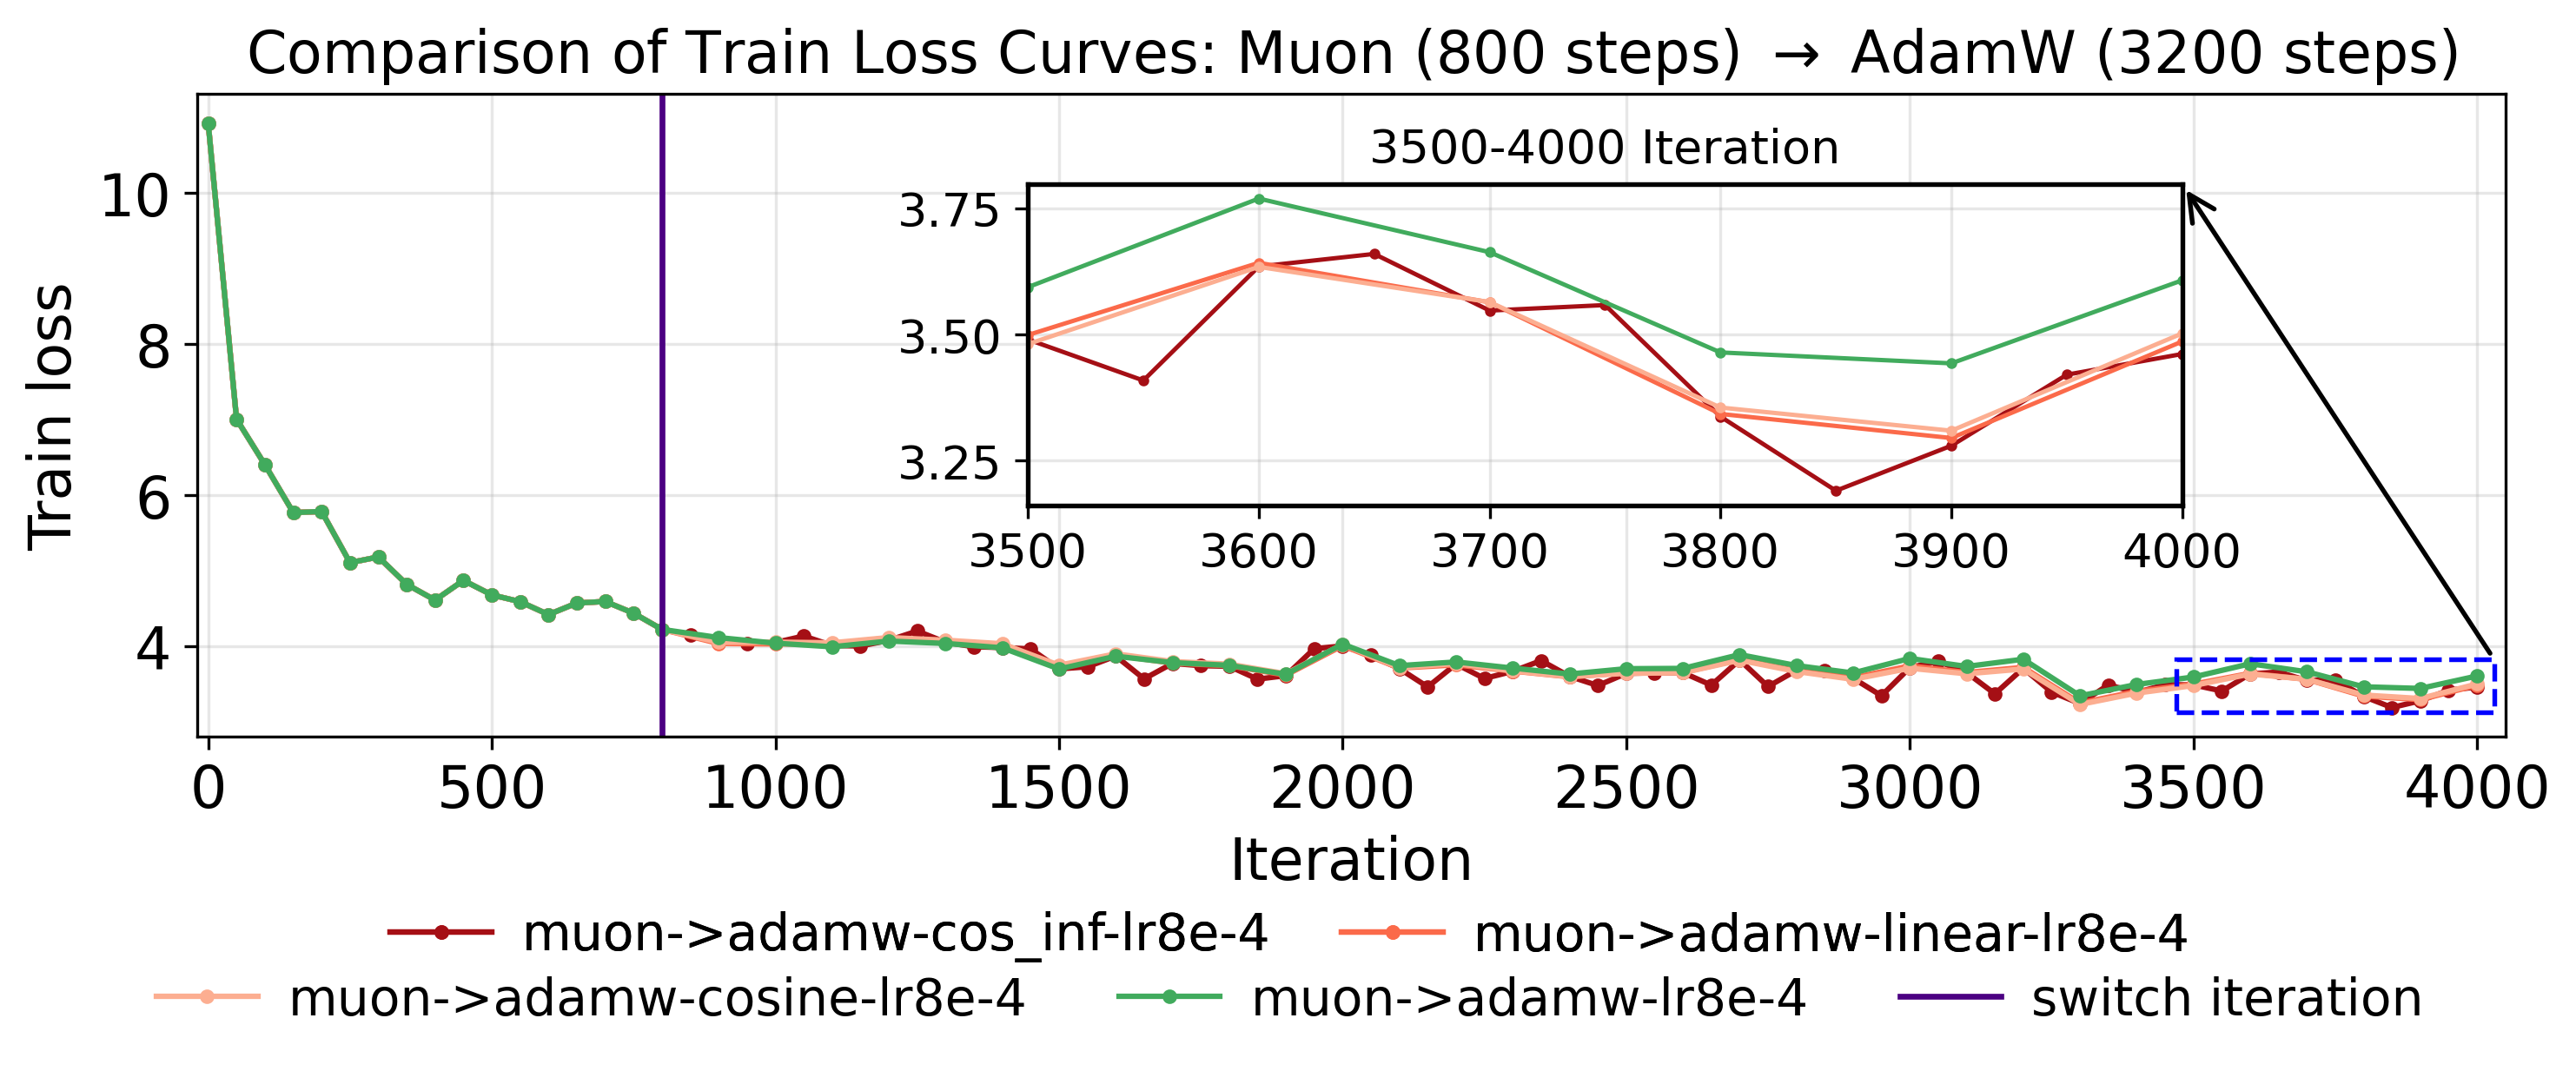

Saved figure to: llm_pretrain_lr_scheduler_muon800adamw3200_train.pdf


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon->adamw-cos_inf-lr8e-4", "muon->adamw-linear-lr8e-4", "muon->adamw-cosine-lr8e-4", "muon->adamw-lr8e-4"]:
    x, y = get_hybrid_curve(df, x_col, "muon800", col_map_train[name], switch_iter, "train", keep="post")
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Train Loss Curves: Muon (800 steps) $\to$ AdamW (3200 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Train loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.36, 0.36, 0.50, 0.50])
for name in ["muon->adamw-cos_inf-lr8e-4", "muon->adamw-linear-lr8e-4", "muon->adamw-cosine-lr8e-4", "muon->adamw-lr8e-4"]:
    x, y = get_hybrid_curve(df, x_col, "muon800", col_map_train[name], switch_iter, "train", keep="post")
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_hybrid_curve(df, x_col, "muon800", col_map_train["muon->adamw-cos_inf-lr8e-4"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon800", col_map_train["muon->adamw-linear-lr8e-4"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon800", col_map_train["muon->adamw-cosine-lr8e-4"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon800", col_map_train["muon->adamw-lr8e-4"], switch_iter, "train", keep="post"),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(1.0, 1.0),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon->adamw-cos_inf-lr8e-4", "muon->adamw-linear-lr8e-4"]
row2 = ["muon->adamw-cosine-lr8e-4", "muon->adamw-lr8e-4", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon800adamw3200_train.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon800adamw3200_train.pdf")
plt.close()

### Experiment0 result of val loss curves: Muon (800 steps) $\to$ AdamW (3200 steps)

In [6]:
csv_path = "llm_pretrain_lr_scheduler/800muon+3200adamw-val.csv"
df = pd.read_csv(csv_path)
print(df.columns)
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon800_series = df[[x_col, col_map_val["muon800"]]].dropna()
if muon800_series.empty:
    raise ValueError("Column 'muon800 - val/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon800_series[x_col].max())

Index(['iter', 'muon+adamwcos--lr8e-4 - val/loss',
       'muon+adamwcos--lr8e-4 - val/loss__MIN',
       'muon+adamwcos--lr8e-4 - val/loss__MAX',
       'muon+adamwcos--lr8e-4 - _step', 'muon+adamwcos--lr8e-4 - _step__MIN',
       'muon+adamwcos--lr8e-4 - _step__MAX',
       'muon+adamwcos_inf--lr8e-4 - val/loss',
       'muon+adamwcos_inf--lr8e-4 - val/loss__MIN',
       'muon+adamwcos_inf--lr8e-4 - val/loss__MAX',
       'muon+adamwcos_inf--lr8e-4 - _step',
       'muon+adamwcos_inf--lr8e-4 - _step__MIN',
       'muon+adamwcos_inf--lr8e-4 - _step__MAX',
       'muon+adamwlinear--lr8e-4 - val/loss',
       'muon+adamwlinear--lr8e-4 - val/loss__MIN',
       'muon+adamwlinear--lr8e-4 - val/loss__MAX',
       'muon+adamwlinear--lr8e-4 - _step',
       'muon+adamwlinear--lr8e-4 - _step__MIN',
       'muon+adamwlinear--lr8e-4 - _step__MAX',
       'muon+adamw--lr8e-4 - val/loss', 'muon+adamw--lr8e-4 - val/loss__MIN',
       'muon+adamw--lr8e-4 - val/loss__MAX', 'muon+adamw--lr8e-4 - _step

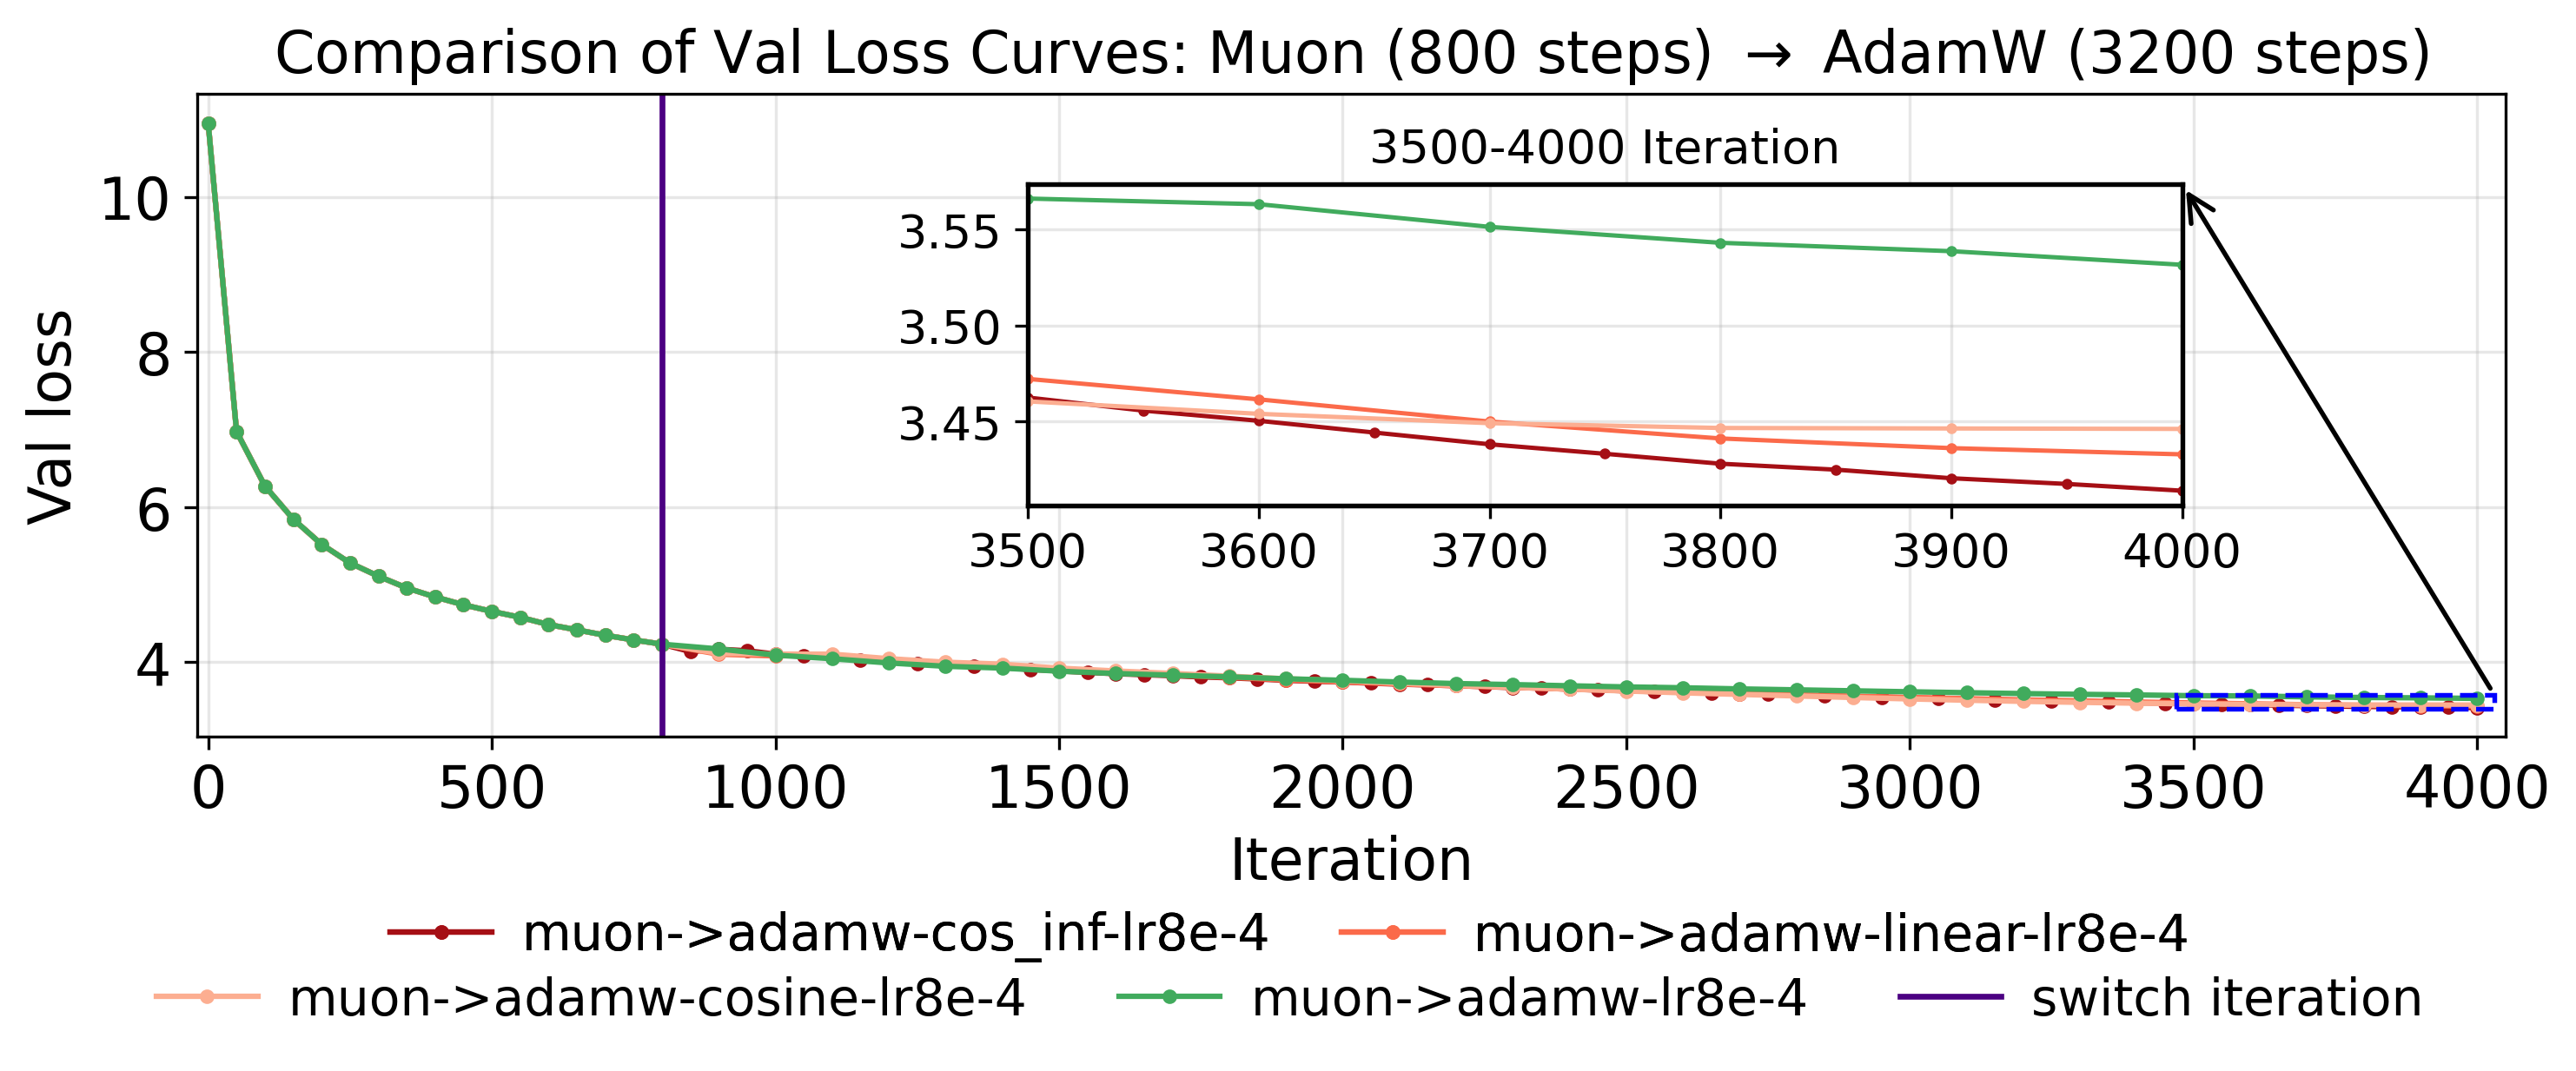

Saved figure to: llm_pretrain_lr_scheduler_muon800adamw3200_val.pdf


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon->adamw-cos_inf-lr8e-4", "muon->adamw-linear-lr8e-4", "muon->adamw-cosine-lr8e-4", "muon->adamw-lr8e-4"]:
    x, y = get_hybrid_curve(df, x_col, "muon800", col_map_val[name], switch_iter, "val", keep="post")
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Val Loss Curves: Muon (800 steps) $\to$ AdamW (3200 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Val loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.36, 0.36, 0.50, 0.50])
for name in ["muon->adamw-cos_inf-lr8e-4", "muon->adamw-linear-lr8e-4", "muon->adamw-cosine-lr8e-4", "muon->adamw-lr8e-4"]:
    x, y = get_hybrid_curve(df, x_col, "muon800", col_map_val[name], switch_iter, "val", keep="post")
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_hybrid_curve(df, x_col, "muon800", col_map_val["muon->adamw-cos_inf-lr8e-4"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon800", col_map_val["muon->adamw-linear-lr8e-4"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon800", col_map_val["muon->adamw-cosine-lr8e-4"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon800", col_map_val["muon->adamw-lr8e-4"], switch_iter, "val", keep="post"),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(1.0, 1.0),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon->adamw-cos_inf-lr8e-4", "muon->adamw-linear-lr8e-4"]
row2 = ["muon->adamw-cosine-lr8e-4", "muon->adamw-lr8e-4", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon800adamw3200_val.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon800adamw3200_val.pdf")
plt.close()

### Experiment1 result of train loss curves: Muon (1000 steps) $\to$ AdamW (3000 steps)

In [8]:
csv_path = "llm_pretrain_lr_scheduler/1000muon+3000adamw-train.csv"
df = pd.read_csv(csv_path)

# Make sure the x-axis column is numeric
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")

# ===== 1. Determine the switch iteration =====
# We treat "muon1000" as the pre-switch phase of the hybrid run.
# The switch iteration is defined as the last iteration where muon1000 has a valid loss.
muon1000_series = df[[x_col, col_map_train["muon1000"]]].dropna()
if muon1000_series.empty:
    raise ValueError("Column 'muon1000 - train/loss' has no data; cannot determine switch iteration.")

switch_iter = int(muon1000_series[x_col].max())

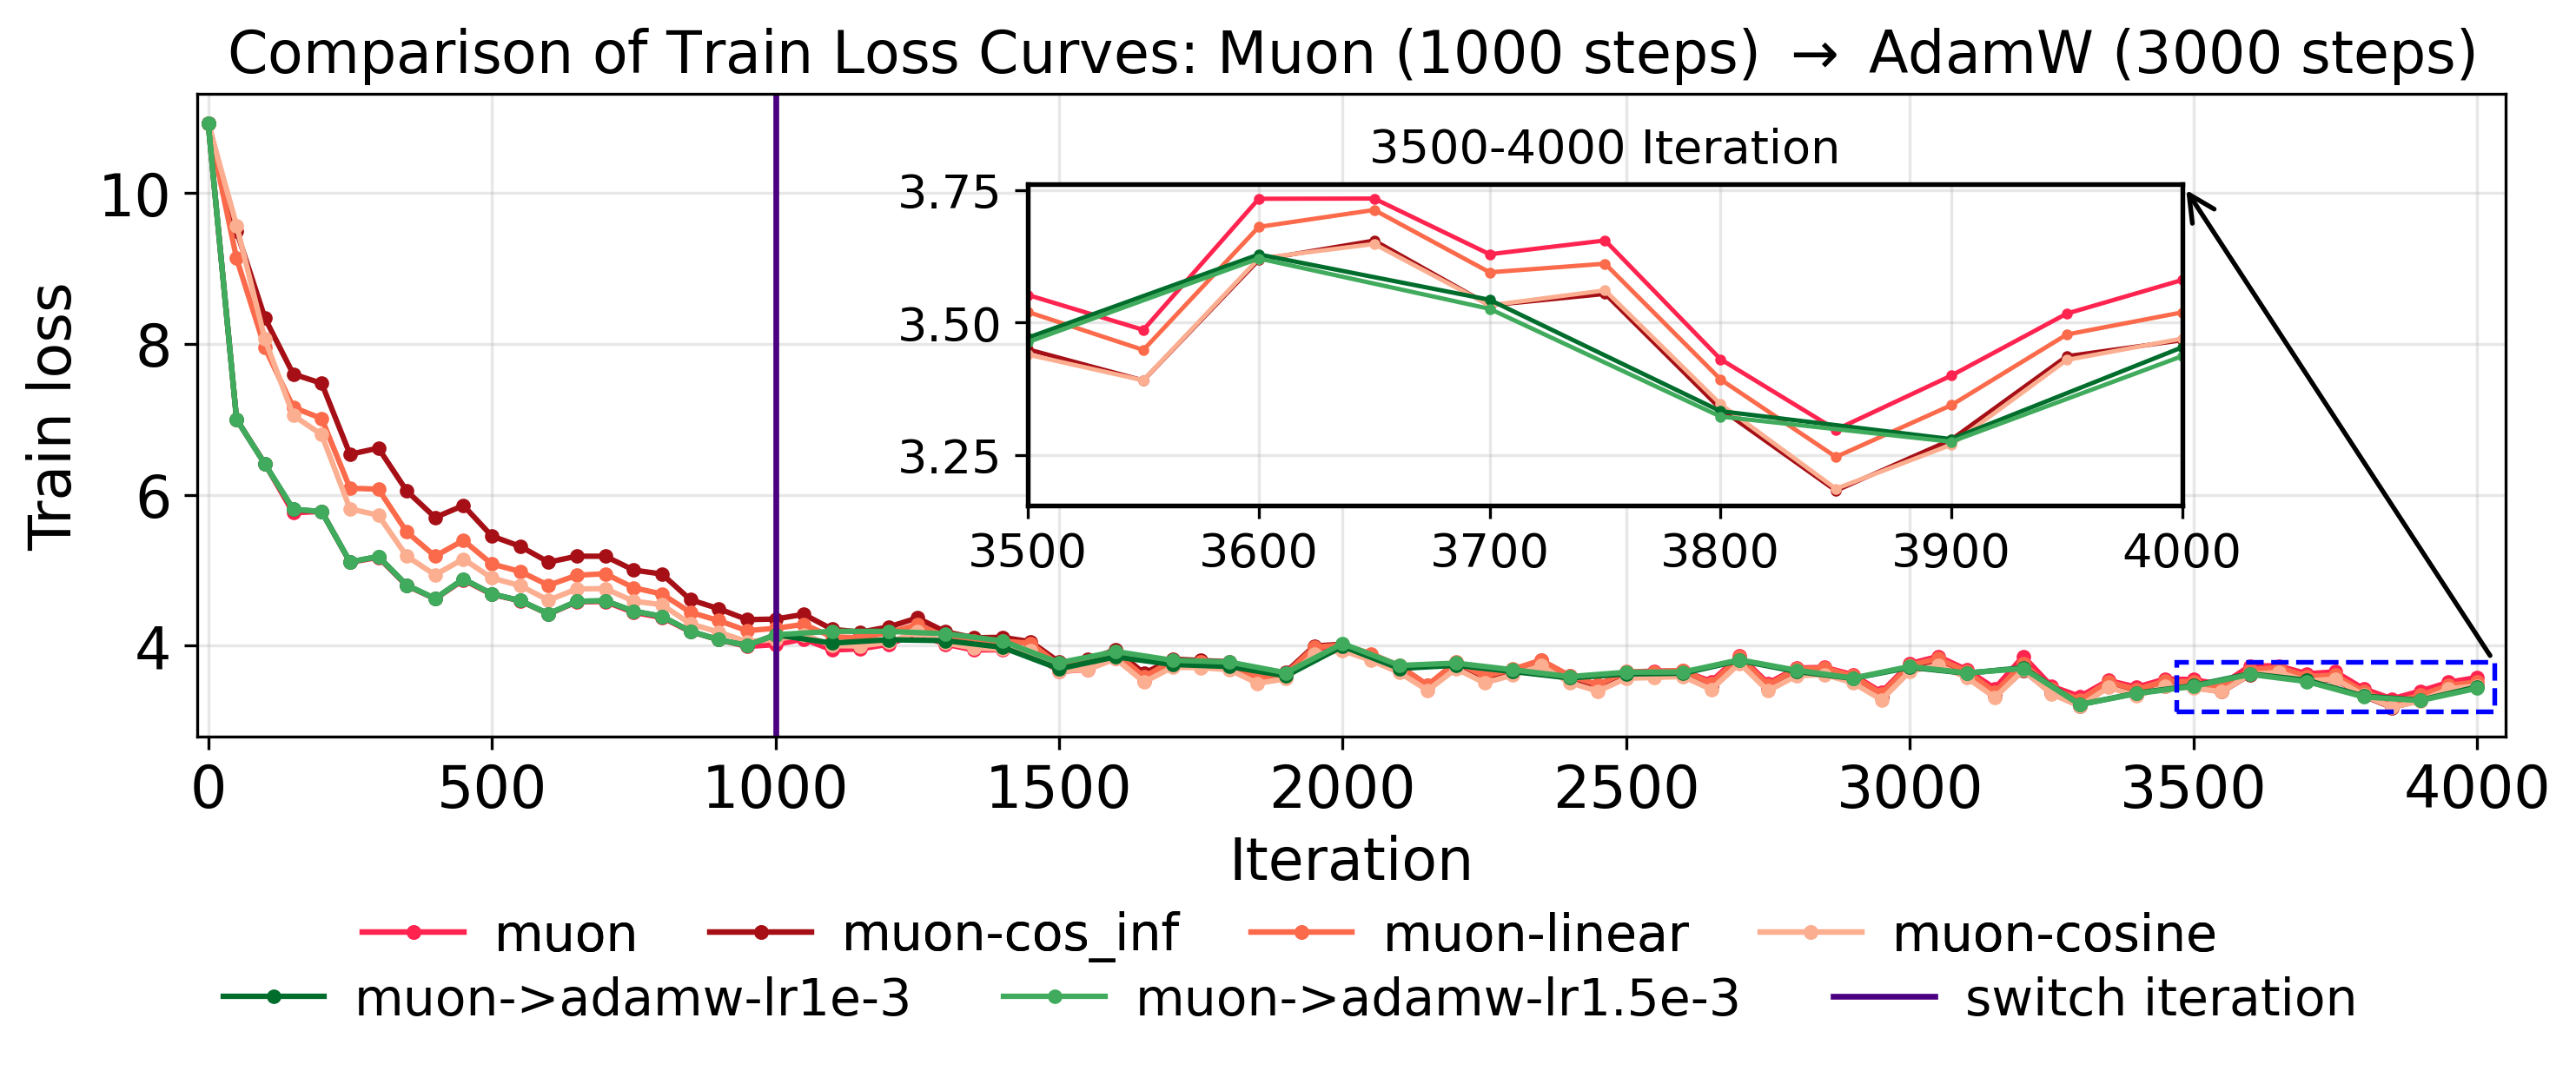

Saved figure to: llm_pretrain_lr_scheduler_muon1000adamw3000_train.pdf


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot the non-hybrid algorithms
for name in ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]:
    x, y = get_curve(df, x_col, col_map_train[name])
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])

# Plot the hybrid algorithms (concatenated curves)
x1, y1 = get_hybrid_curve(df, x_col, "muon1000", col_map_train["muon->adamw-lr1e-3"], switch_iter, "train", keep="post")
ax.plot(x1, y1, marker="o", markersize=3, linewidth=1.5, 
        label="muon->adamw-lr1e-3", color=colors["muon->adamw-lr1e-3"])

x2, y2 = get_hybrid_curve(df, x_col, "muon1000", col_map_train["muon->adamw-lr1.5e-3"], switch_iter, "train", keep="post")
ax.plot(x2, y2, marker="o", markersize=3, linewidth=1.5,
        label="muon->adamw-lr1.5e-3", color=colors["muon->adamw-lr1.5e-3"])

# Draw the vertical switch line (shown once in the legend)
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")

ax.set_title(rf"Comparison of Train Loss Curves: Muon (1000 steps) $\to$ AdamW (3000 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Train loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)

# Create the inset axes (zoom into the last ~500 iters)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter

axins = ax.inset_axes([0.36, 0.36, 0.50, 0.50])

# Plot all selected curves in the inset
for name in ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]:
    x, y = get_curve(df, x_col, col_map_train[name])
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)

plot_on(axins, "muon->adamw-lr1e-3", x1, y1, zoom_x0, zoom_x1)
plot_on(axins, "muon->adamw-lr1.5e-3", x2, y2, zoom_x0, zoom_x1)

axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
# axins.set_xlabel("Iteration", fontsize=9)
# axins.set_ylabel("Train loss", fontsize=9)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)

# Make the inset border thicker and black
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)

# Draw a rectangle on the main plot showing the inset region
# Compute the y-range for the inset window using all plotted curves
all_inset_vals = []
for x, y in [
    get_curve(df, x_col, col_map_train["muon"]),
    get_curve(df, x_col, col_map_train["muon-cos_inf"]),
    get_curve(df, x_col, col_map_train["muon-linear"]),
    get_curve(df, x_col, col_map_train["muon-cosine"]),
    (x1, y1),
    (x2, y2),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])

vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin

# Slightly expand the rectangle beyond the zoom region for aesthetics
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin

rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)

# Add an arrow from the rectangle to the inset axes
# clip_on=False helps avoid rare internal clipping/path issues
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(1.0, 1.0),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)

fig.tight_layout()
fig.subplots_adjust(bottom=0.28)

# Process Legend: 2 rows at the bottom of the whole figure
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]
row2 = ["muon->adamw-lr1e-3", "muon->adamw-lr1.5e-3", "switch iteration"]
# First row (4 items)
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
# Second row (3 items)
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)

plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon1000adamw3000_train.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon1000adamw3000_train.pdf")
plt.close()

### Experiment1 result of val loss curves: Muon (1000 steps) $\to$ AdamW (3000 steps)

In [10]:
csv_path = "llm_pretrain_lr_scheduler/1000muon+3000adamw-val.csv"
df = pd.read_csv(csv_path)
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon1000_series = df[[x_col, col_map_val["muon1000"]]].dropna()
if muon1000_series.empty:
    raise ValueError("Column 'muon1000 - val/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon1000_series[x_col].max())

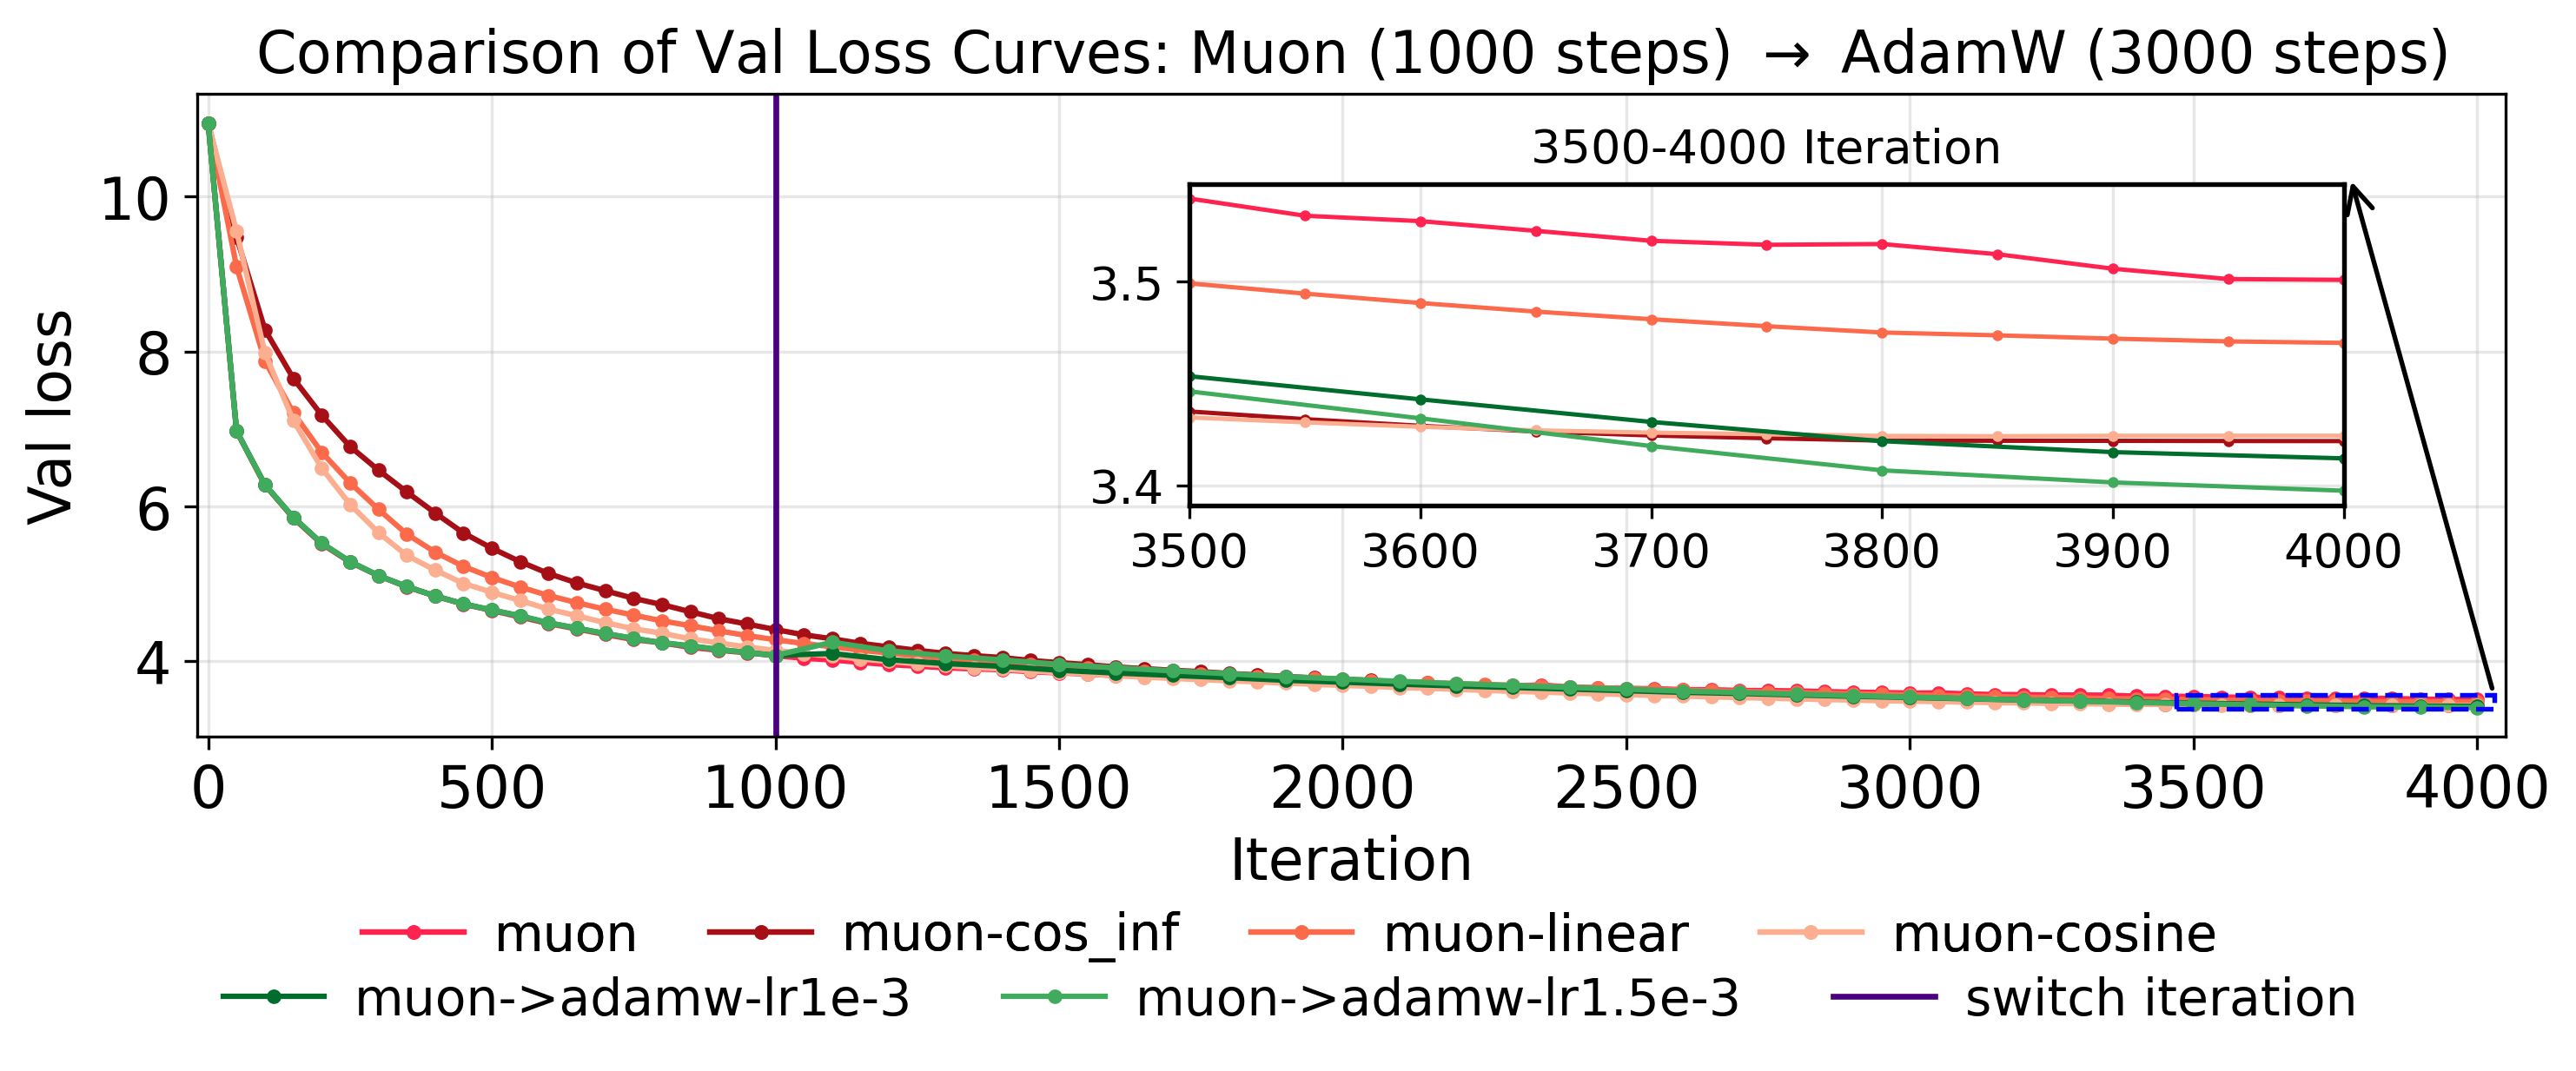

Saved figure to: llm_pretrain_lr_scheduler_muon1000adamw3000_val.pdf


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]:
    x, y = get_curve(df, x_col, col_map_val[name])
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
x1, y1 = get_hybrid_curve(df, x_col, "muon1000", col_map_val["muon->adamw-lr1e-3"], switch_iter, "val", keep="post")
ax.plot(x1, y1, marker="o", markersize=3, linewidth=1.5, 
        label="muon->adamw-lr1e-3", color=colors["muon->adamw-lr1e-3"])
x2, y2 = get_hybrid_curve(df, x_col, "muon1000", col_map_val["muon->adamw-lr1.5e-3"], switch_iter, "val", keep="post")
ax.plot(x2, y2, marker="o", markersize=3, linewidth=1.5, 
        label="muon->adamw-lr1.5e-3", color=colors["muon->adamw-lr1.5e-3"])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Val Loss Curves: Muon (1000 steps) $\to$ AdamW (3000 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Val loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.43, 0.36, 0.50, 0.50])
for name in ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]:
    x, y = get_curve(df, x_col, col_map_val[name])
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
plot_on(axins, "muon->adamw-lr1e-3", x1, y1, zoom_x0, zoom_x1)
plot_on(axins, "muon->adamw-lr1.5e-3", x2, y2, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_curve(df, x_col, col_map_val["muon"]),
    get_curve(df, x_col, col_map_val["muon-cos_inf"]),
    get_curve(df, x_col, col_map_val["muon-linear"]),
    get_curve(df, x_col, col_map_val["muon-cosine"]),
    (x1, y1),
    (x2, y2),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(1.005, 1.03),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]
row2 = ["muon->adamw-lr1e-3", "muon->adamw-lr1.5e-3", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon1000adamw3000_val.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon1000adamw3000_val.pdf")
plt.close()

### Experiment2 result of train loss curves: Muon (1500 steps) $\to$ AdamW (2500 steps)

In [12]:
csv_path = "llm_pretrain_lr_scheduler/1500muon+2500adamw-train.csv"
df = pd.read_csv(csv_path)
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon1500_series = df[[x_col, col_map_train["muon1500"]]].dropna()
if muon1500_series.empty:
    raise ValueError("Column 'muon1500 - train/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon1500_series[x_col].max())

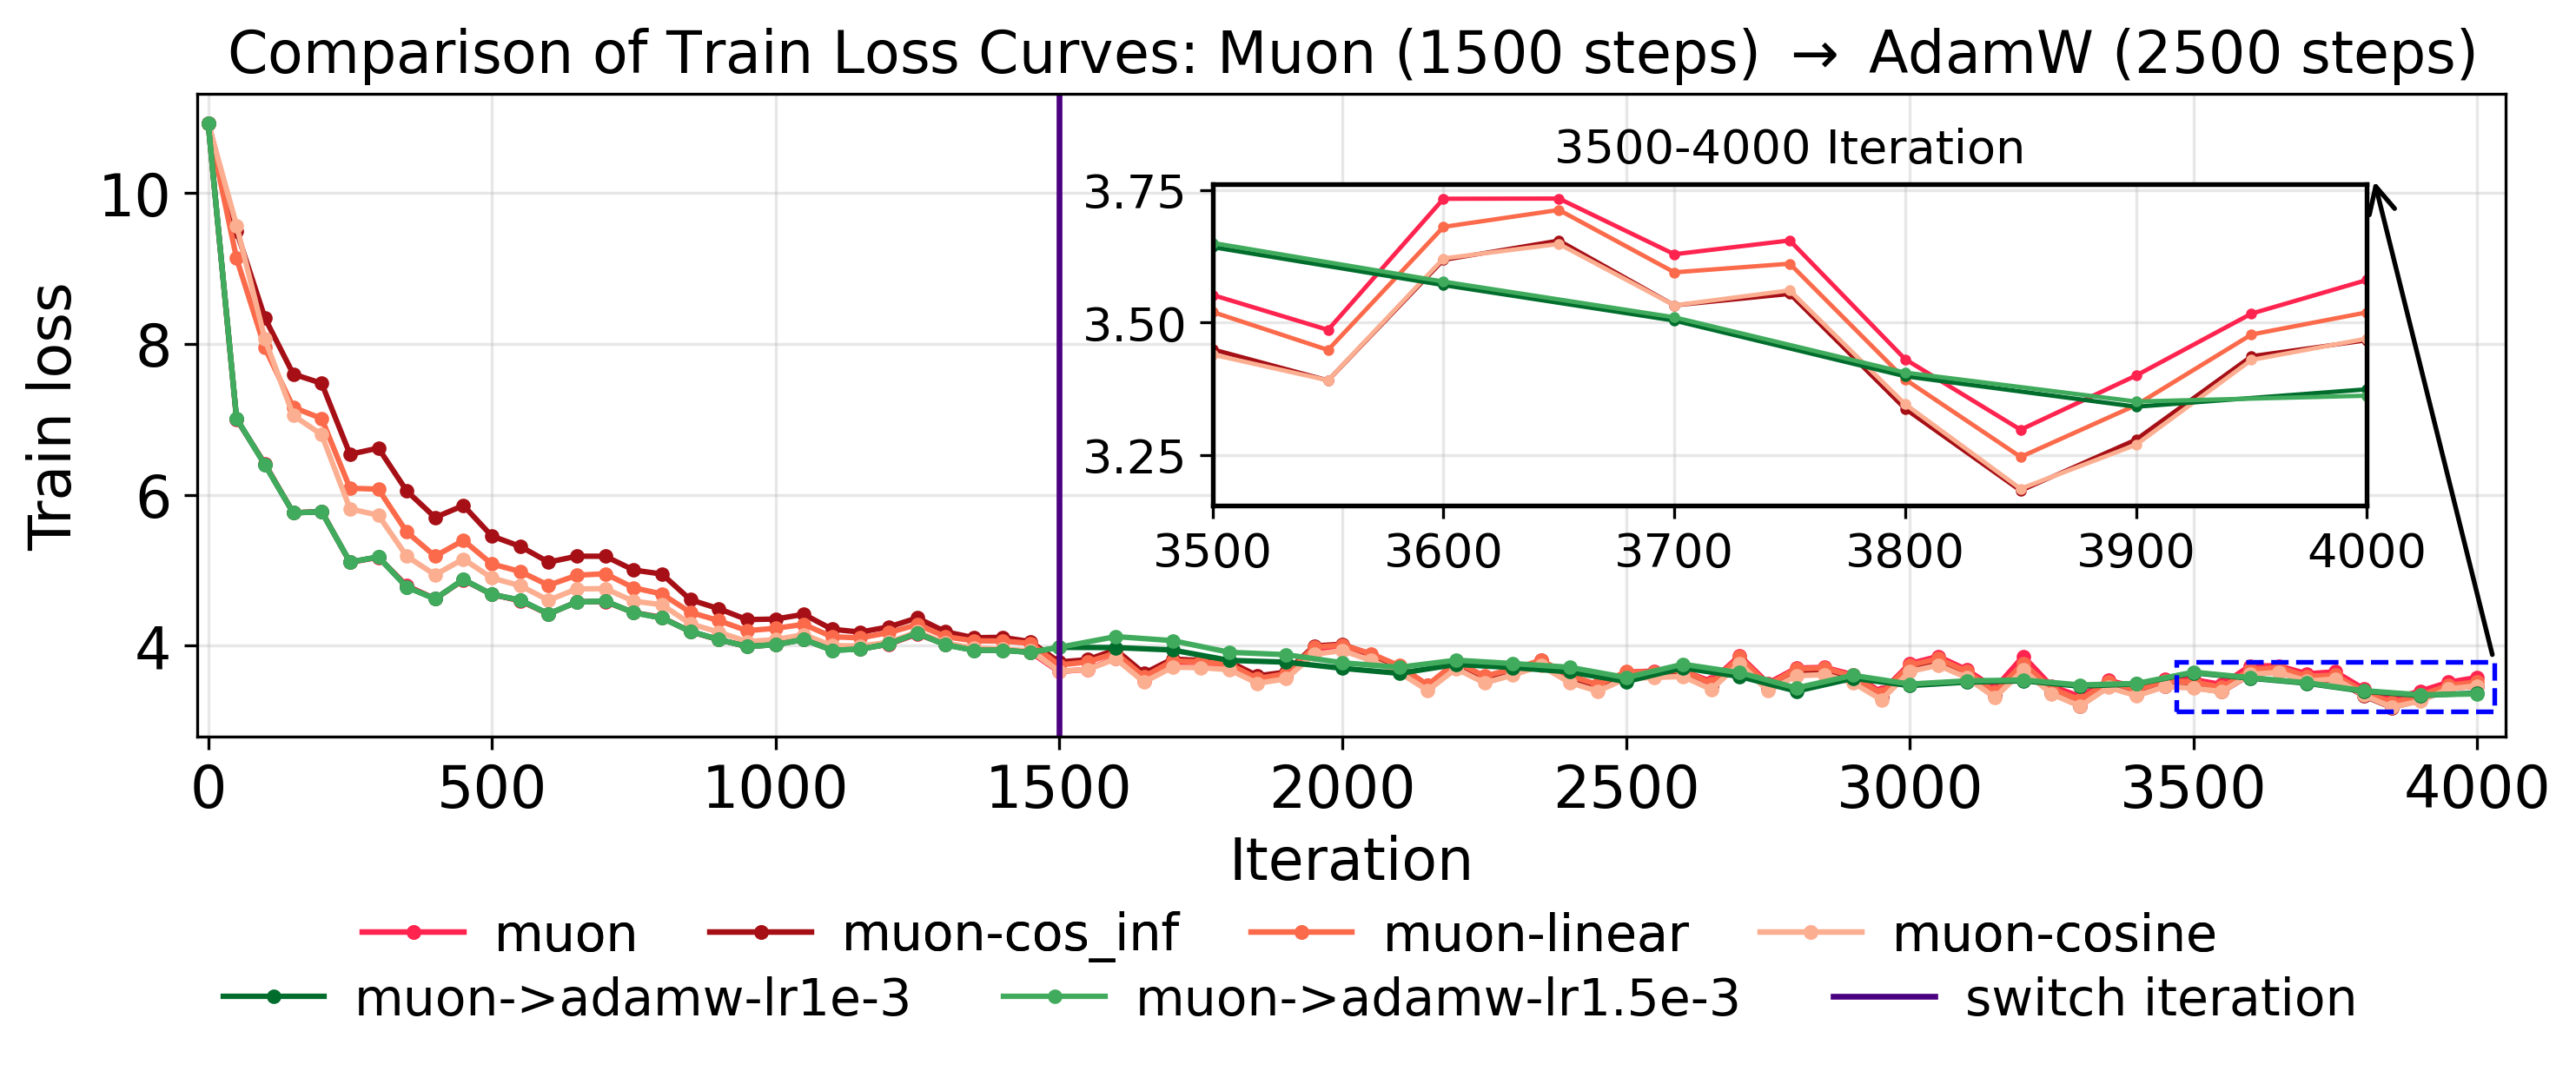

Saved figure to: llm_pretrain_lr_scheduler_muon1500adamw2500_train.pdf


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]:
    x, y = get_curve(df, x_col, col_map_train[name])
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
x1, y1 = get_hybrid_curve(df, x_col, "muon1500", col_map_train["muon->adamw-lr1e-3"], switch_iter, "train", keep="post")
ax.plot(x1, y1, marker="o", markersize=3, linewidth=1.5, 
        label="muon->adamw-lr1e-3", color=colors["muon->adamw-lr1e-3"])
x2, y2 = get_hybrid_curve(df, x_col, "muon1500", col_map_train["muon->adamw-lr1.5e-3"], switch_iter, "train", keep="post")
ax.plot(x2, y2, marker="o", markersize=3, linewidth=1.5,
        label="muon->adamw-lr1.5e-3", color=colors["muon->adamw-lr1.5e-3"])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Train Loss Curves: Muon (1500 steps) $\to$ AdamW (2500 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Train loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.44, 0.36, 0.50, 0.50])
for name in ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]:
    x, y = get_curve(df, x_col, col_map_train[name])
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
plot_on(axins, "muon->adamw-lr1e-3", x1, y1, zoom_x0, zoom_x1)
plot_on(axins, "muon->adamw-lr1.5e-3", x2, y2, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_curve(df, x_col, col_map_train["muon"]),
    get_curve(df, x_col, col_map_train["muon-cos_inf"]),
    get_curve(df, x_col, col_map_train["muon-linear"]),
    get_curve(df, x_col, col_map_train["muon-cosine"]),
    (x1, y1),
    (x2, y2),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(1.005, 1.03),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]
row2 = ["muon->adamw-lr1e-3", "muon->adamw-lr1.5e-3", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon1500adamw2500_train.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon1500adamw2500_train.pdf")
plt.close()

### Experiment2 result of val loss curves: Muon (1500 steps) $\to$ AdamW (2500 steps)

In [14]:
csv_path = "llm_pretrain_lr_scheduler/1500muon+2500adamw-val.csv"
df = pd.read_csv(csv_path)
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon1500_series = df[[x_col, col_map_val["muon1500"]]].dropna()
if muon1500_series.empty:
    raise ValueError("Column 'muon1500 - val/loss' has no data; cannot determine switch iteration.")

switch_iter = int(muon1500_series[x_col].max())

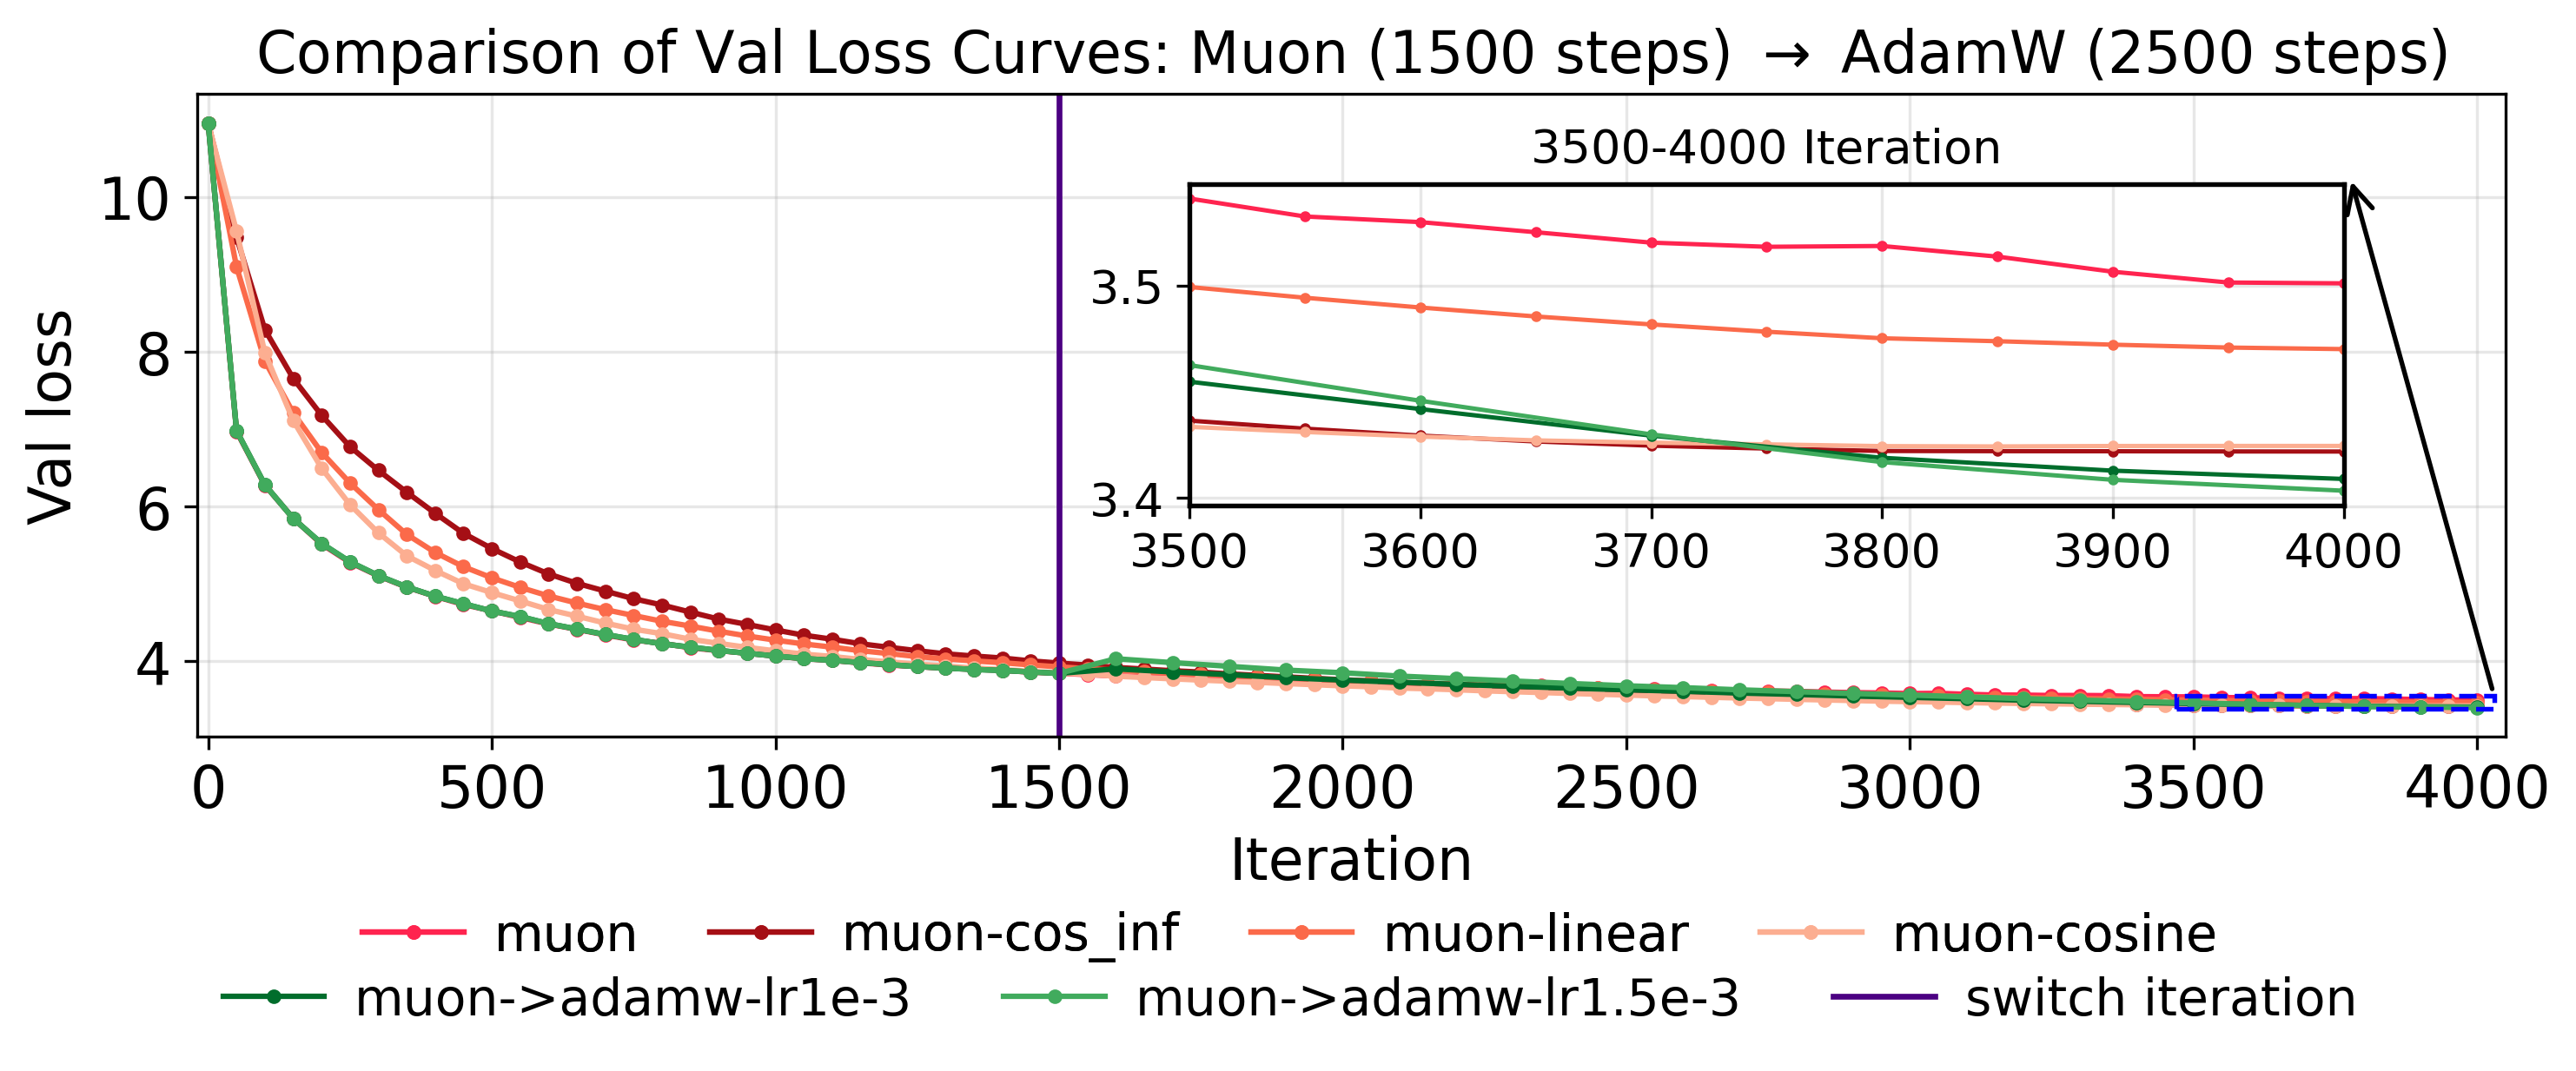

Saved figure to: llm_pretrain_lr_scheduler_muon1500adamw2500_val.pdf


In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]:
    x, y = get_curve(df, x_col, col_map_val[name])
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
x1, y1 = get_hybrid_curve(df, x_col, "muon1500", col_map_val["muon->adamw-lr1e-3"], switch_iter, "val", keep="post")
ax.plot(x1, y1, marker="o", markersize=3, linewidth=1.5, 
        label="muon->adamw-lr1e-3", color=colors["muon->adamw-lr1e-3"])
x2, y2 = get_hybrid_curve(df, x_col, "muon1500", col_map_val["muon->adamw-lr1.5e-3"], switch_iter, "val", keep="post")
ax.plot(x2, y2, marker="o", markersize=3, linewidth=1.5,
        label="muon->adamw-lr1.5e-3", color=colors["muon->adamw-lr1.5e-3"])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Val Loss Curves: Muon (1500 steps) $\to$ AdamW (2500 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Val loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.43, 0.36, 0.50, 0.50])
for name in ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]:
    x, y = get_curve(df, x_col, col_map_val[name])
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
plot_on(axins, "muon->adamw-lr1e-3", x1, y1, zoom_x0, zoom_x1)
plot_on(axins, "muon->adamw-lr1.5e-3", x2, y2, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_curve(df, x_col, col_map_val["muon"]),
    get_curve(df, x_col, col_map_val["muon-cos_inf"]),
    get_curve(df, x_col, col_map_val["muon-linear"]),
    get_curve(df, x_col, col_map_val["muon-cosine"]),
    (x1, y1),
    (x2, y2),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(1.005, 1.03),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon", "muon-cos_inf", "muon-linear", "muon-cosine"]
row2 = ["muon->adamw-lr1e-3", "muon->adamw-lr1.5e-3", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon1500adamw2500_val.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon1500adamw2500_val.pdf")
plt.close()

### Experiment3 result of train loss curves: Muon (2000 steps) $\to$ AdamW (2000 steps)

In [16]:
csv_path = "llm_pretrain_lr_scheduler/2000muon+2000adamw-train.csv"
df = pd.read_csv(csv_path)
#print(df.columns)  # different from the former two cases
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon2000_series = df[[x_col, col_map_train["muon2000"]]].dropna()
if muon2000_series.empty:
    raise ValueError("Column 'muon2000 - train/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon2000_series[x_col].max())

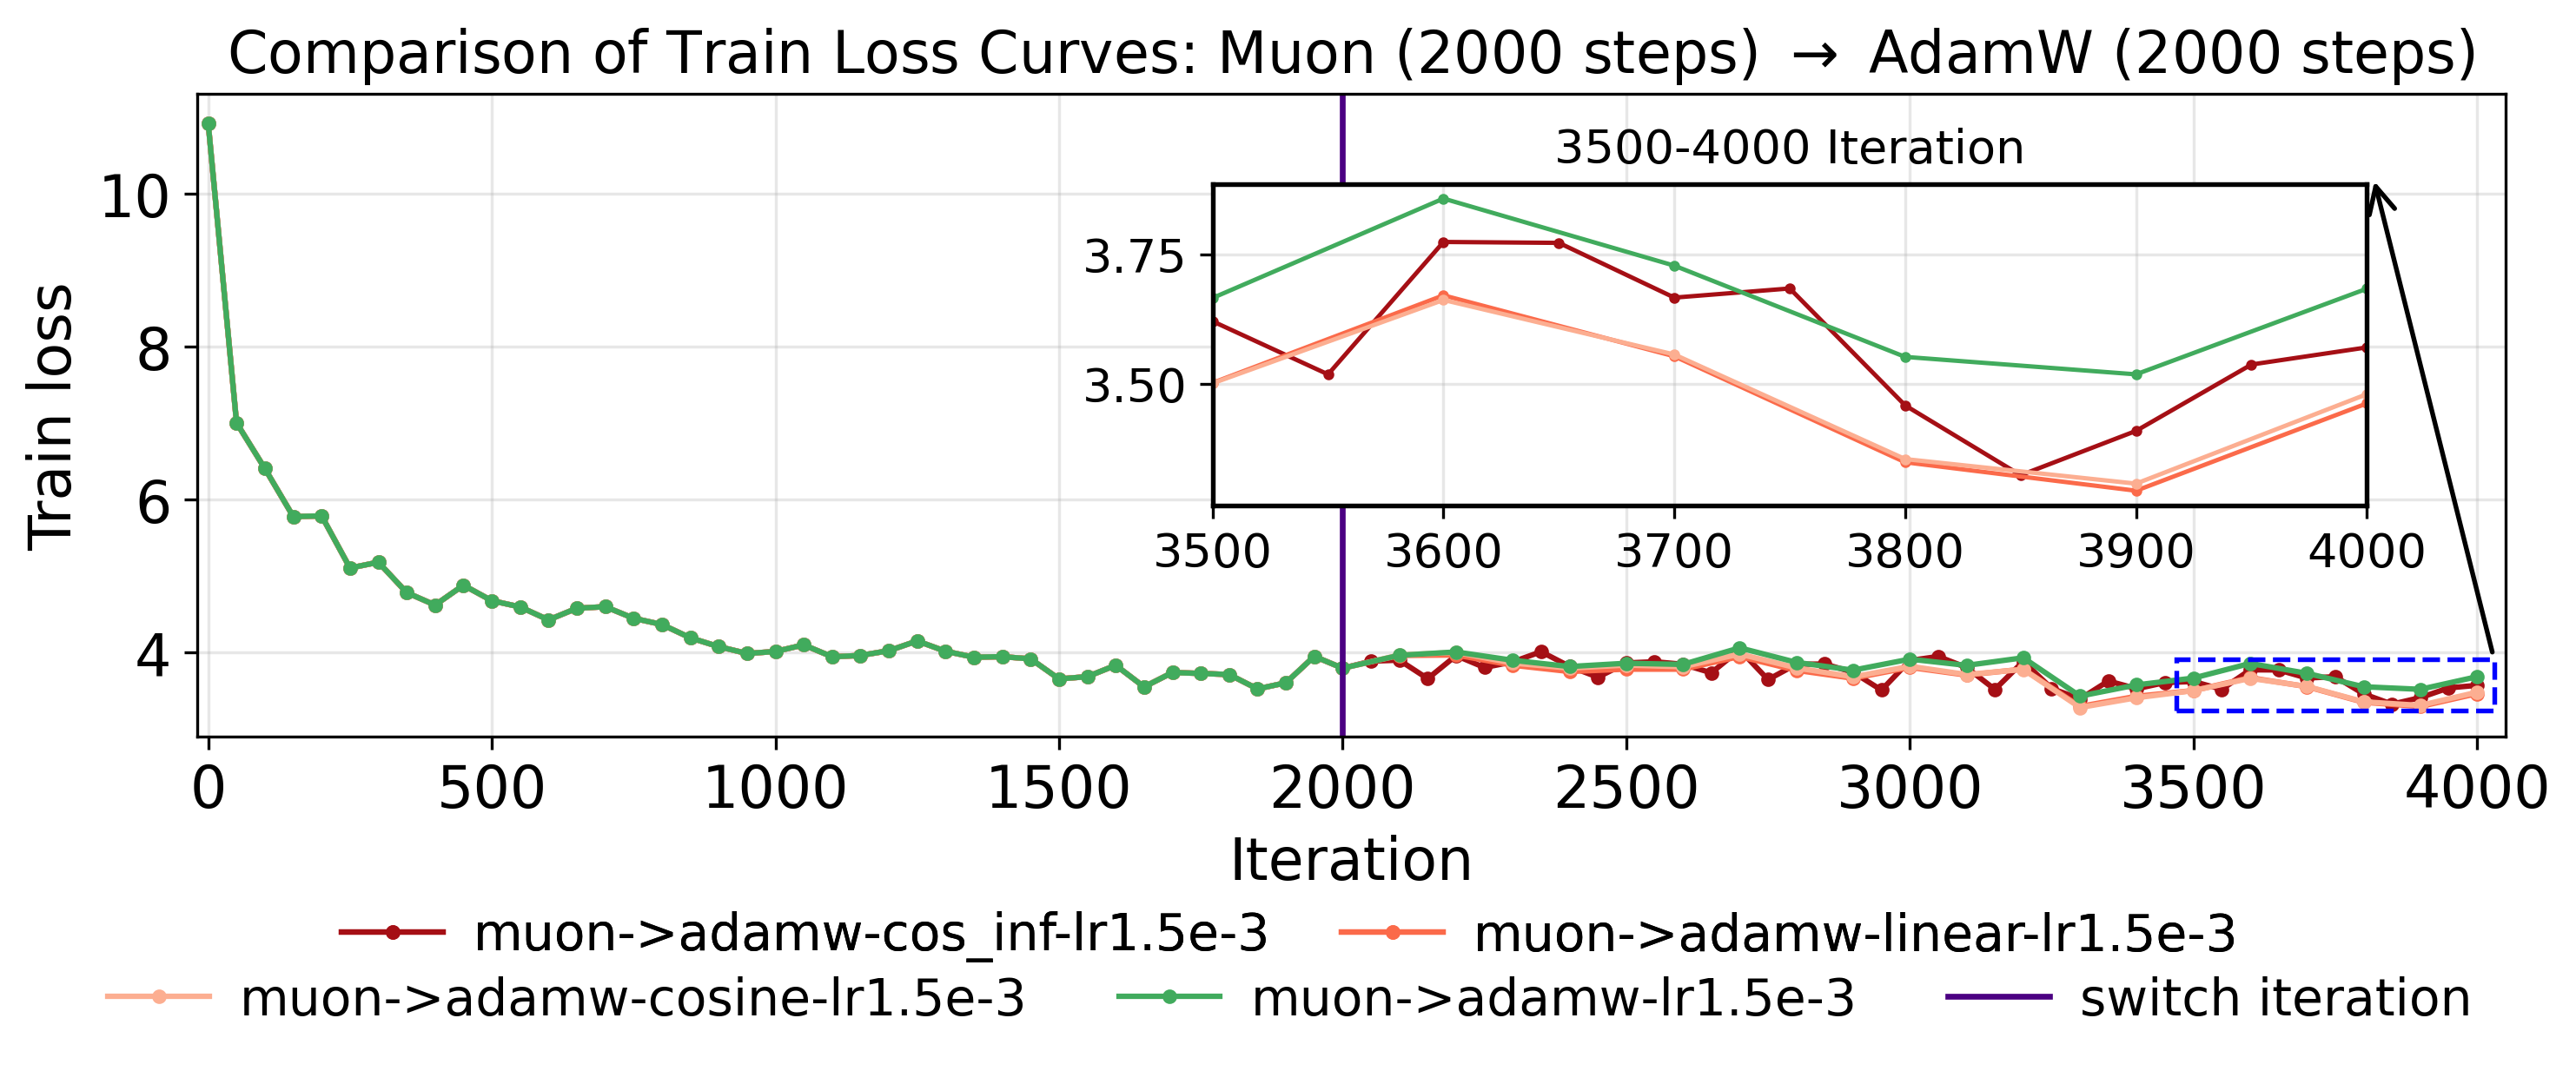

Saved figure to: llm_pretrain_lr_scheduler_muon2000adamw2000_train.pdf


In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon->adamw-cos_inf-lr1.5e-3", "muon->adamw-linear-lr1.5e-3", "muon->adamw-cosine-lr1.5e-3", "muon->adamw-lr1.5e-3"]:
    x, y = get_hybrid_curve(df, x_col, "muon2000", col_map_train[name], switch_iter, "train", keep="post")
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Train Loss Curves: Muon (2000 steps) $\to$ AdamW (2000 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Train loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.44, 0.36, 0.50, 0.50])
for name in ["muon->adamw-cos_inf-lr1.5e-3", "muon->adamw-linear-lr1.5e-3", "muon->adamw-cosine-lr1.5e-3", "muon->adamw-lr1.5e-3"]:
    x, y = get_hybrid_curve(df, x_col, "muon2000", col_map_train[name], switch_iter, "train", keep="post")
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_hybrid_curve(df, x_col, "muon2000", col_map_train["muon->adamw-cos_inf-lr1.5e-3"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon2000", col_map_train["muon->adamw-linear-lr1.5e-3"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon2000", col_map_train["muon->adamw-cosine-lr1.5e-3"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon2000", col_map_train["muon->adamw-lr1.5e-3"], switch_iter, "train", keep="post"),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(1.005, 1.03),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon->adamw-cos_inf-lr1.5e-3", "muon->adamw-linear-lr1.5e-3"]
row2 = ["muon->adamw-cosine-lr1.5e-3", "muon->adamw-lr1.5e-3", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon2000adamw2000_train.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon2000adamw2000_train.pdf")
plt.close()

### Experiment3 result of val loss curves: Muon (2000 steps) $\to$ AdamW (2000 steps)

In [18]:
csv_path = "llm_pretrain_lr_scheduler/2000muon+2000adamw-val.csv"
df = pd.read_csv(csv_path)
#print(df.columns)  # different from the former two cases
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon2000_series = df[[x_col, col_map_val["muon2000"]]].dropna()
if muon2000_series.empty:
    raise ValueError("Column 'muon2000 - val/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon2000_series[x_col].max())

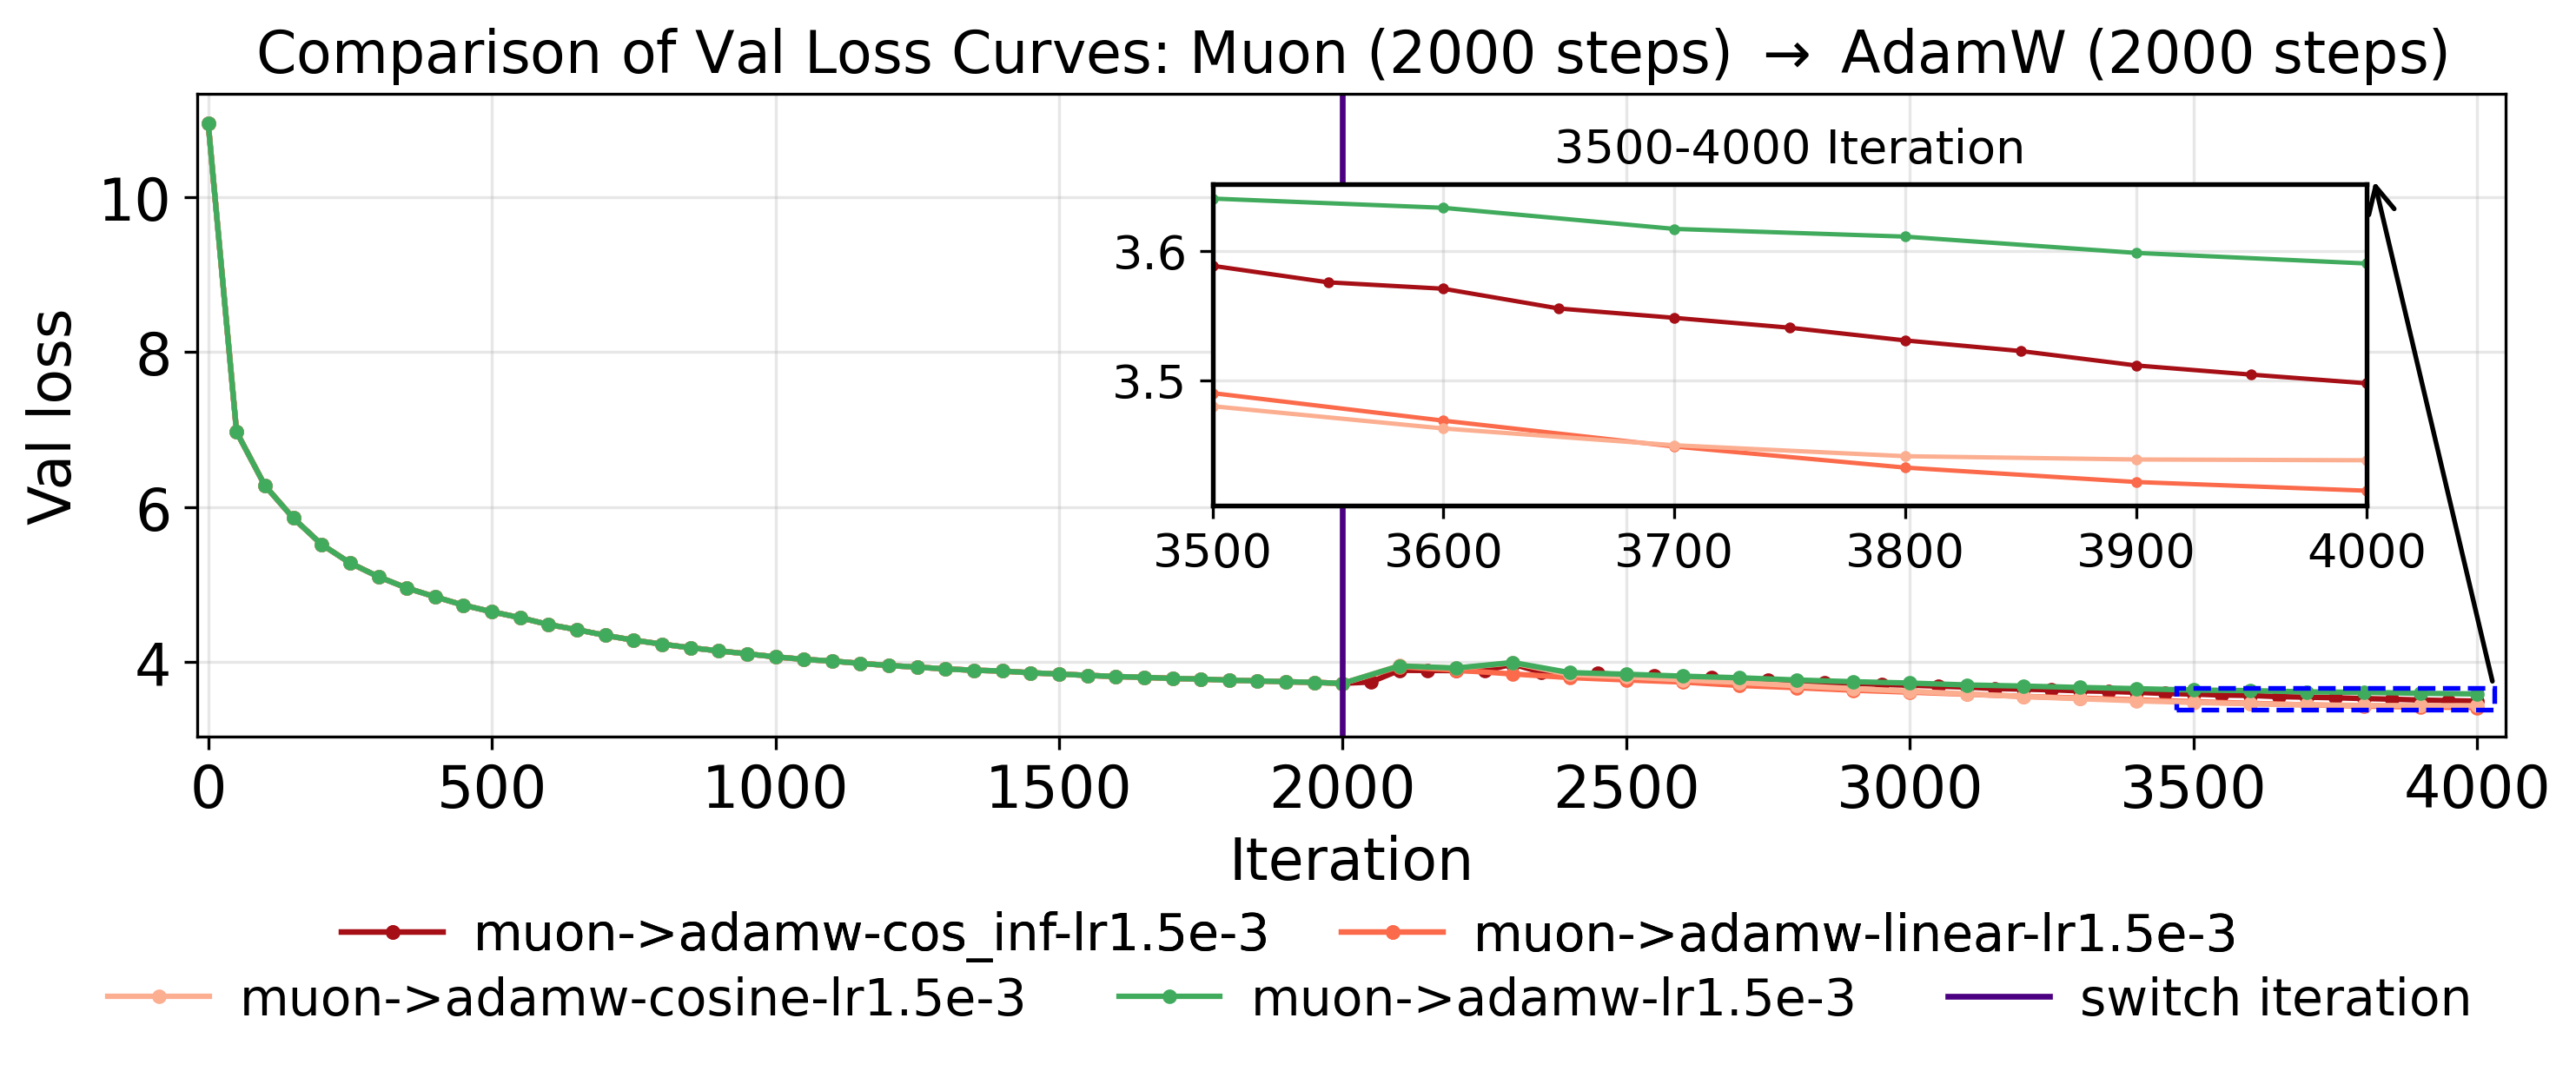

Saved figure to: llm_pretrain_lr_scheduler_muon2000adamw2000_val.pdf


In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon->adamw-cos_inf-lr1.5e-3", "muon->adamw-linear-lr1.5e-3", "muon->adamw-cosine-lr1.5e-3", "muon->adamw-lr1.5e-3"]:
    x, y = get_hybrid_curve(df, x_col, "muon2000", col_map_val[name], switch_iter, "val", keep="post")
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Val Loss Curves: Muon (2000 steps) $\to$ AdamW (2000 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Val loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.44, 0.36, 0.50, 0.50])
for name in ["muon->adamw-cos_inf-lr1.5e-3", "muon->adamw-linear-lr1.5e-3", "muon->adamw-cosine-lr1.5e-3", "muon->adamw-lr1.5e-3"]:
    x, y = get_hybrid_curve(df, x_col, "muon2000", col_map_val[name], switch_iter, "val", keep="post")
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_hybrid_curve(df, x_col, "muon2000", col_map_val["muon->adamw-cos_inf-lr1.5e-3"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon2000", col_map_val["muon->adamw-linear-lr1.5e-3"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon2000", col_map_val["muon->adamw-cosine-lr1.5e-3"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon2000", col_map_val["muon->adamw-lr1.5e-3"], switch_iter, "val", keep="post"),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(1.005, 1.03),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon->adamw-cos_inf-lr1.5e-3", "muon->adamw-linear-lr1.5e-3"]
row2 = ["muon->adamw-cosine-lr1.5e-3", "muon->adamw-lr1.5e-3", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon2000adamw2000_val.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon2000adamw2000_val.pdf")
plt.close()

### Experiment4 result of train loss curves: Muon (3000 steps) $\to$ AdamW (1000 steps)

In [20]:
csv_path = "llm_pretrain_lr_scheduler/3000muon+1000adamw-train.csv"
df = pd.read_csv(csv_path)
#print(df.columns)  # different from the former two cases
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon3000_series = df[[x_col, col_map_train["muon3000"]]].dropna()
if muon3000_series.empty:
    raise ValueError("Column 'muon3000 - train/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon3000_series[x_col].max())

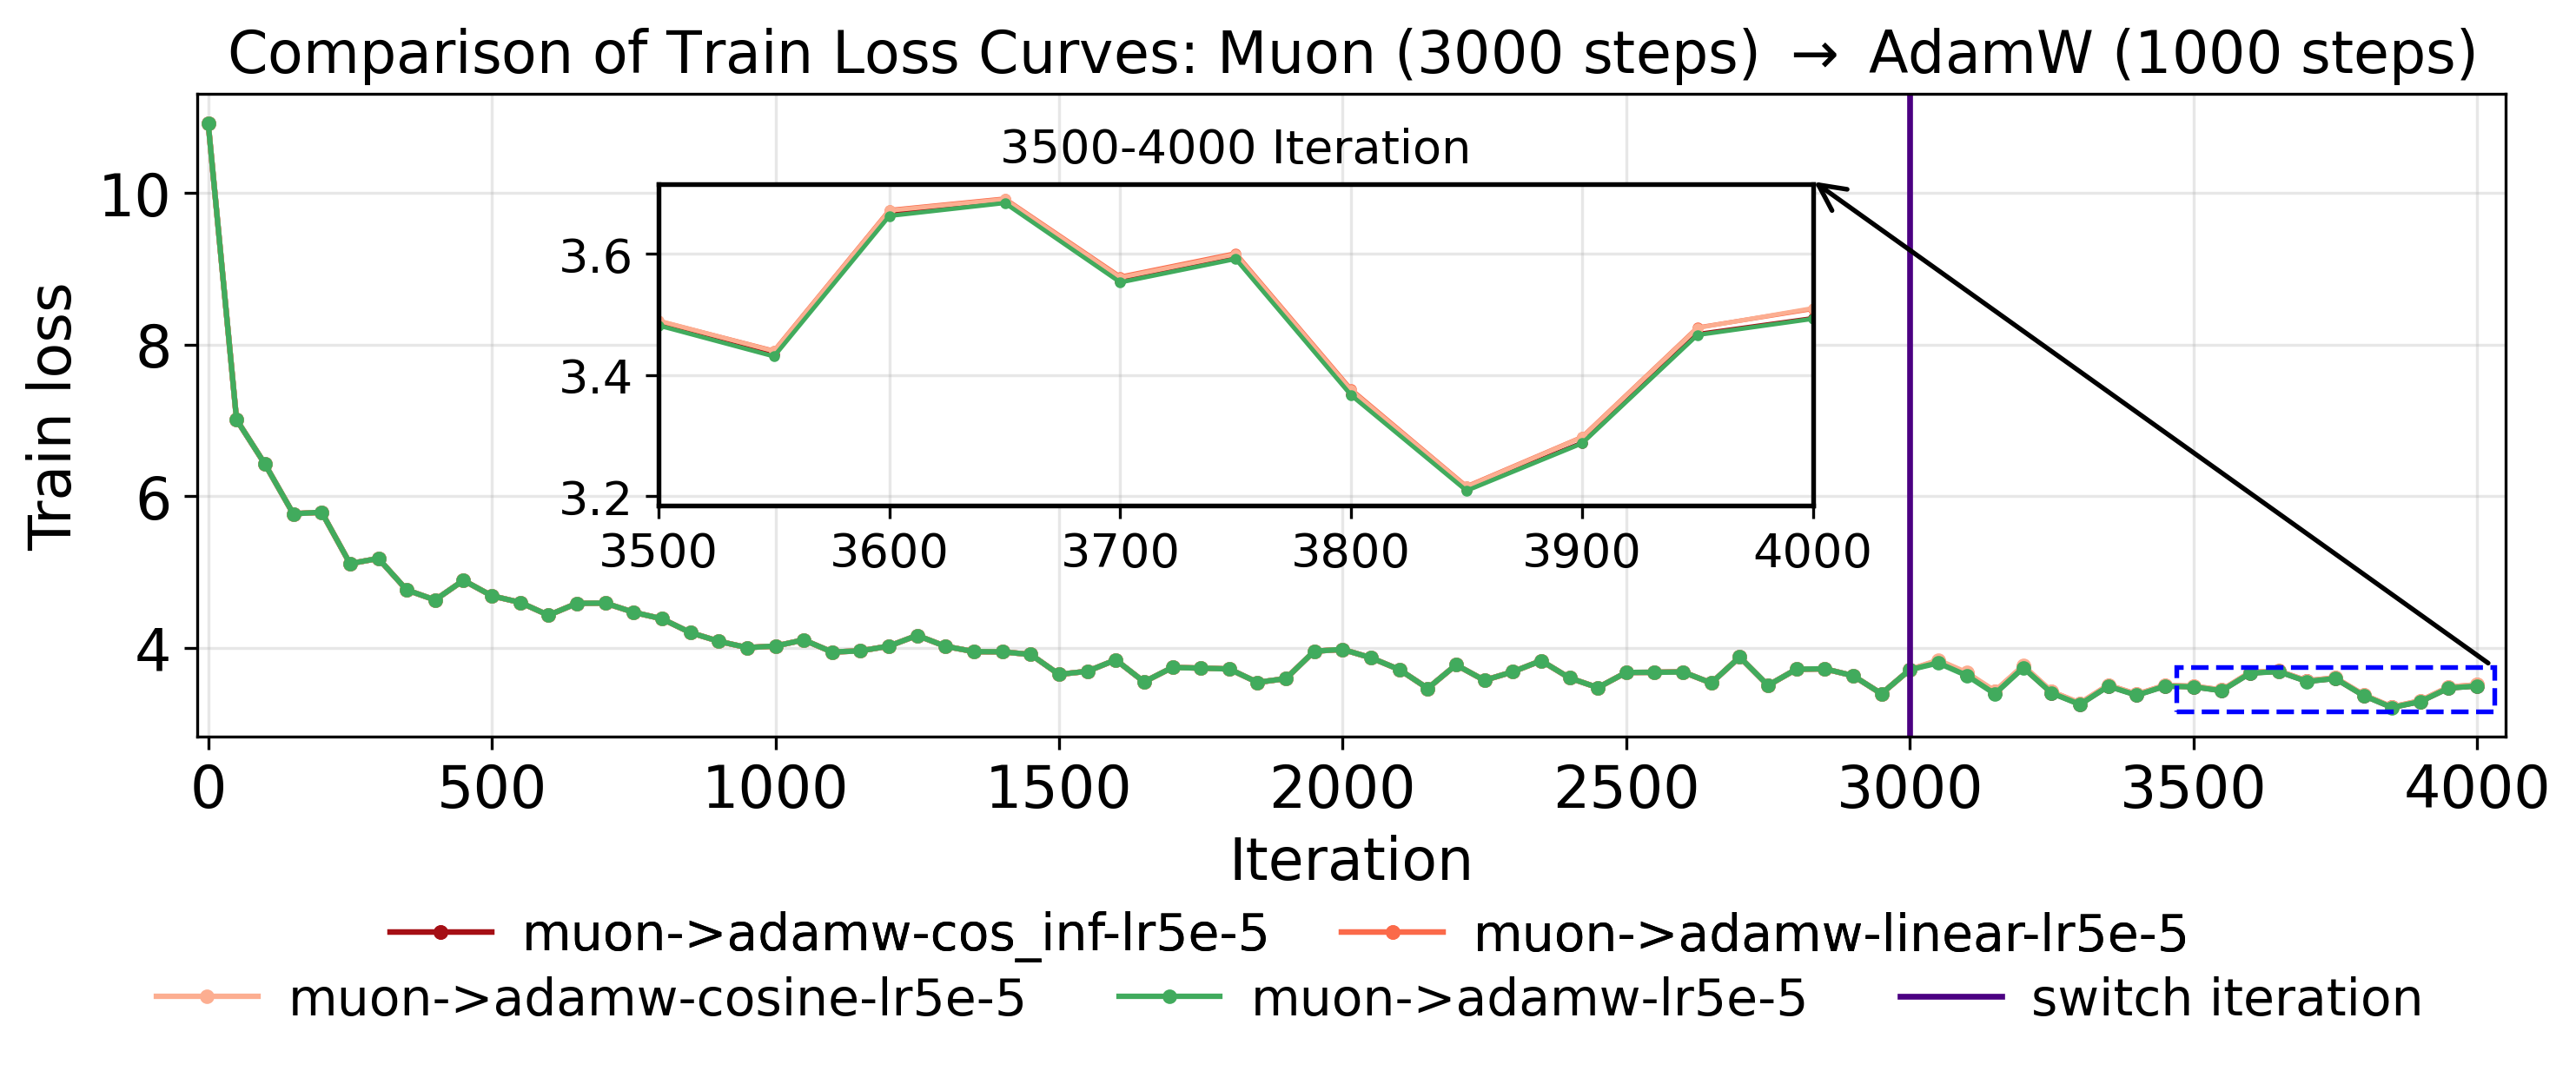

Saved figure to: llm_pretrain_lr_scheduler_muon3000adamw1000_train.pdf


In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon->adamw-cos_inf-lr5e-5", "muon->adamw-linear-lr5e-5", "muon->adamw-cosine-lr5e-5", "muon->adamw-lr5e-5"]:
    x, y = get_hybrid_curve(df, x_col, "muon3000", col_map_train[name], switch_iter, "train", keep="post")
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Train Loss Curves: Muon (3000 steps) $\to$ AdamW (1000 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Train loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.20, 0.36, 0.50, 0.50])
for name in ["muon->adamw-cos_inf-lr5e-5", "muon->adamw-linear-lr5e-5", "muon->adamw-cosine-lr5e-5", "muon->adamw-lr5e-5"]:
    x, y = get_hybrid_curve(df, x_col, "muon3000", col_map_train[name], switch_iter, "train", keep="post")
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_hybrid_curve(df, x_col, "muon3000", col_map_train["muon->adamw-cos_inf-lr5e-5"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon3000", col_map_train["muon->adamw-linear-lr5e-5"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon3000", col_map_train["muon->adamw-cosine-lr5e-5"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon3000", col_map_train["muon->adamw-lr5e-5"], switch_iter, "train", keep="post"),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(0.996, 1.02),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon->adamw-cos_inf-lr5e-5", "muon->adamw-linear-lr5e-5"]
row2 = ["muon->adamw-cosine-lr5e-5", "muon->adamw-lr5e-5", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon3000adamw1000_train.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon3000adamw1000_train.pdf")
plt.close()

### Experiment4 result of val loss curves: Muon (3000 steps) $\to$ AdamW (1000 steps)

In [22]:
csv_path = "llm_pretrain_lr_scheduler/3000muon+1000adamw-val.csv"
df = pd.read_csv(csv_path)
#print(df.columns)  # different from the former two cases
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon3000_series = df[[x_col, col_map_val["muon3000"]]].dropna()
if muon3000_series.empty:
    raise ValueError("Column 'muon3000 - val/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon3000_series[x_col].max())

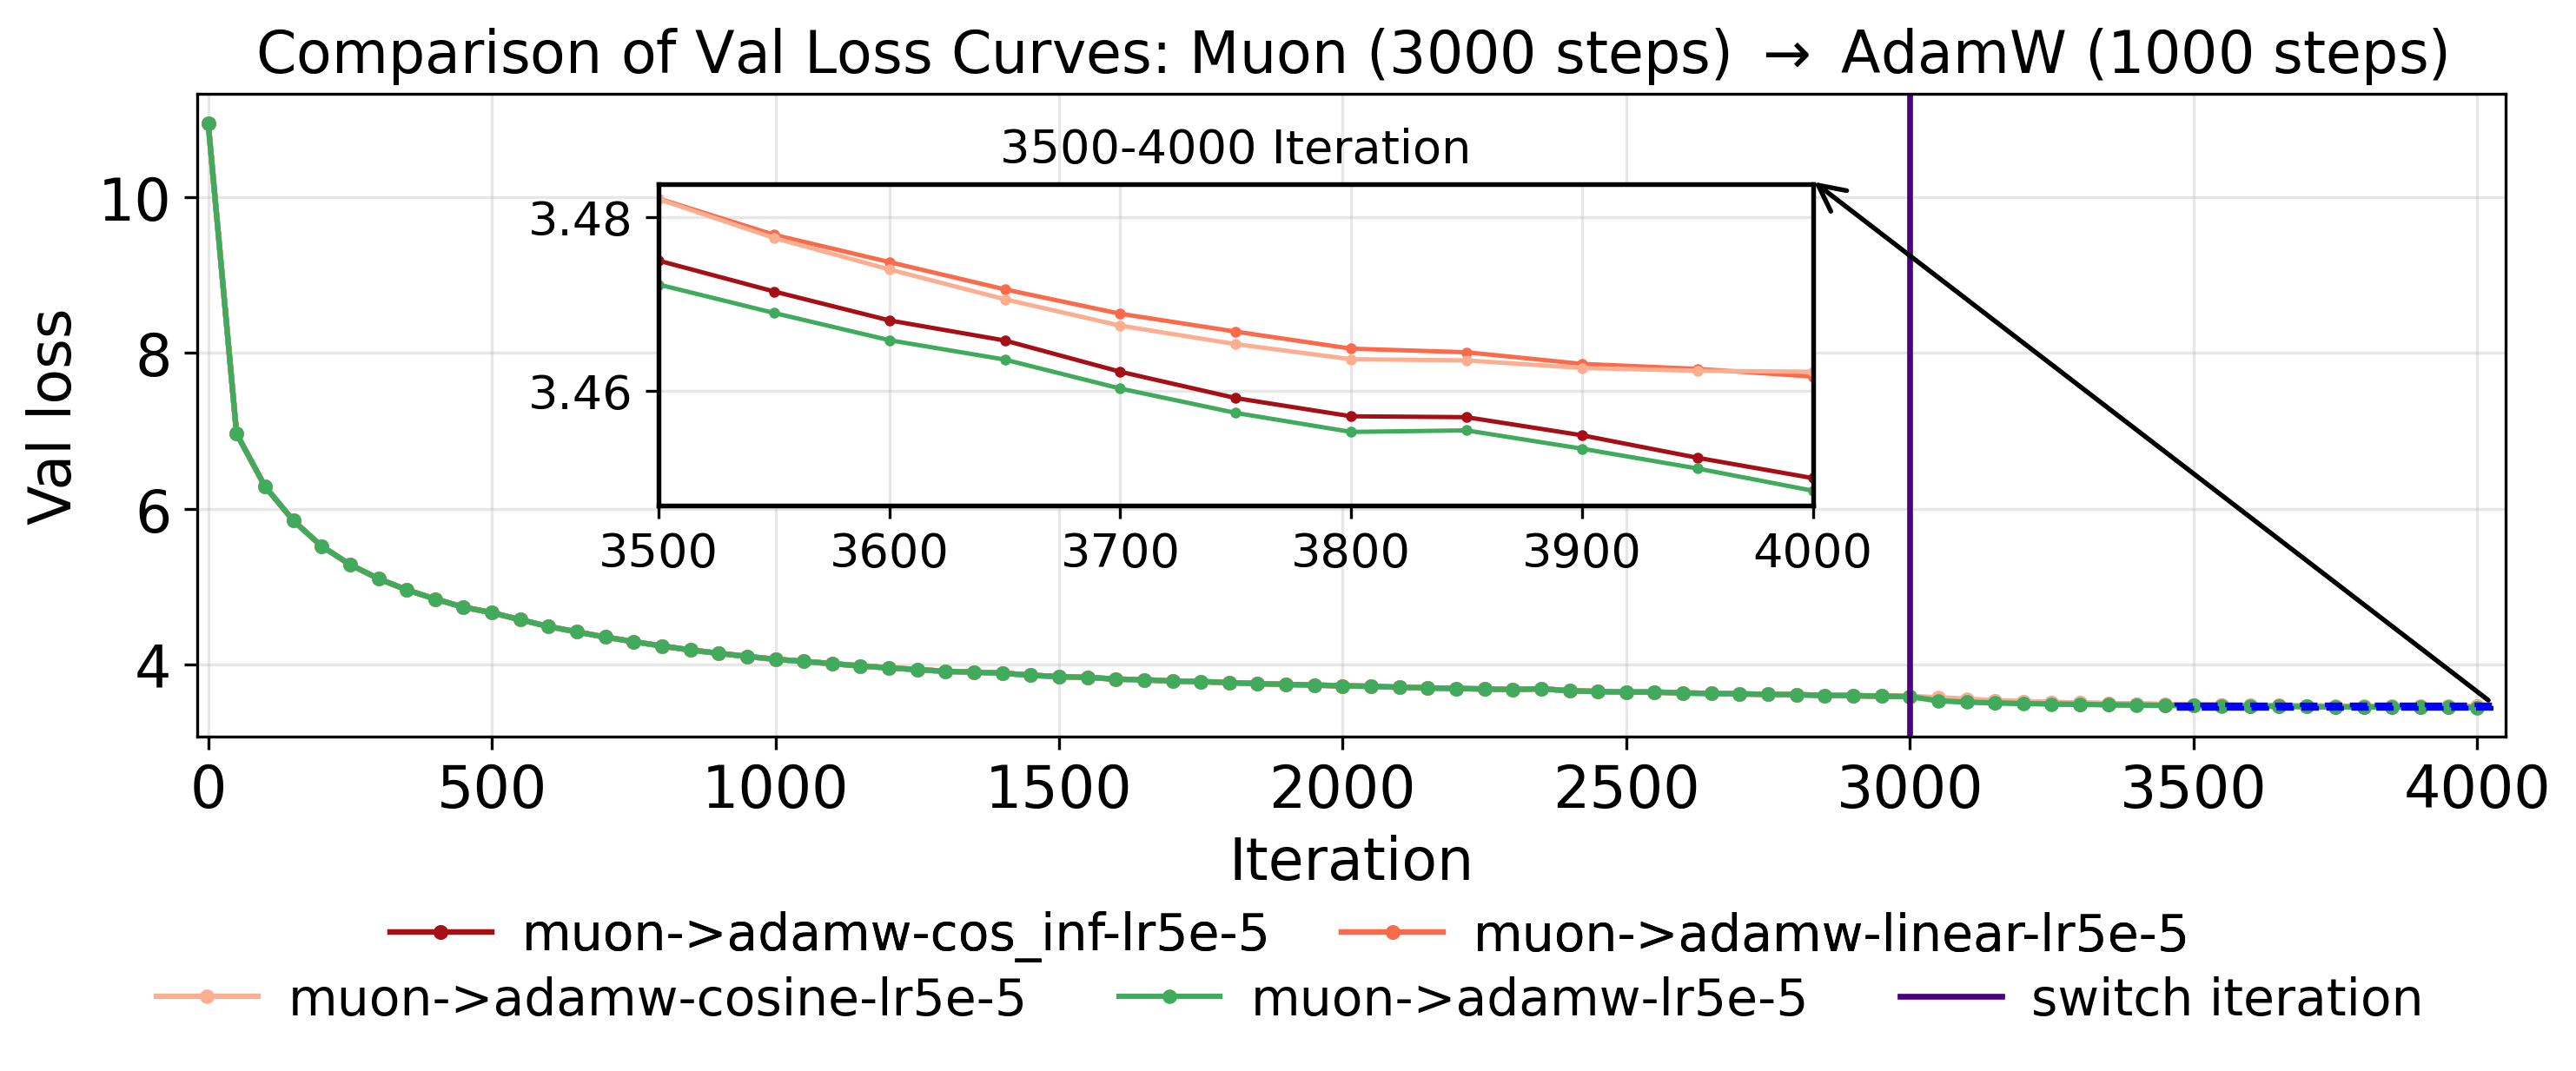

Saved figure to: llm_pretrain_lr_scheduler_muon3000adamw1000_val.pdf


In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon->adamw-cos_inf-lr5e-5", "muon->adamw-linear-lr5e-5", "muon->adamw-cosine-lr5e-5", "muon->adamw-lr5e-5"]:
    x, y = get_hybrid_curve(df, x_col, "muon3000", col_map_val[name], switch_iter, "val", keep="post")
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Val Loss Curves: Muon (3000 steps) $\to$ AdamW (1000 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Val loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.20, 0.36, 0.50, 0.50])
for name in ["muon->adamw-cos_inf-lr5e-5", "muon->adamw-linear-lr5e-5", "muon->adamw-cosine-lr5e-5", "muon->adamw-lr5e-5"]:
    x, y = get_hybrid_curve(df, x_col, "muon3000", col_map_val[name], switch_iter, "val", keep="post")
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_hybrid_curve(df, x_col, "muon3000", col_map_val["muon->adamw-cos_inf-lr5e-5"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon3000", col_map_val["muon->adamw-linear-lr5e-5"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon3000", col_map_val["muon->adamw-cosine-lr5e-5"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon3000", col_map_val["muon->adamw-lr5e-5"], switch_iter, "val", keep="post"),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(0.996, 1.02),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon->adamw-cos_inf-lr5e-5", "muon->adamw-linear-lr5e-5"]
row2 = ["muon->adamw-cosine-lr5e-5", "muon->adamw-lr5e-5", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon3000adamw1000_val.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon3000adamw1000_val.pdf")
plt.close()

### Experiment5 result of train loss curves: Muon (3750 steps) $\to$ AdamW (250 steps)

In [24]:
csv_path = "llm_pretrain_lr_scheduler/3750muon+250adamw-train.csv"
df = pd.read_csv(csv_path)
#print(df.columns)  # different from the former two cases
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon3750_series = df[[x_col, col_map_train["muon3750"]]].dropna()
if muon3750_series.empty:
    raise ValueError("Column 'muon3750 - train/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon3750_series[x_col].max())

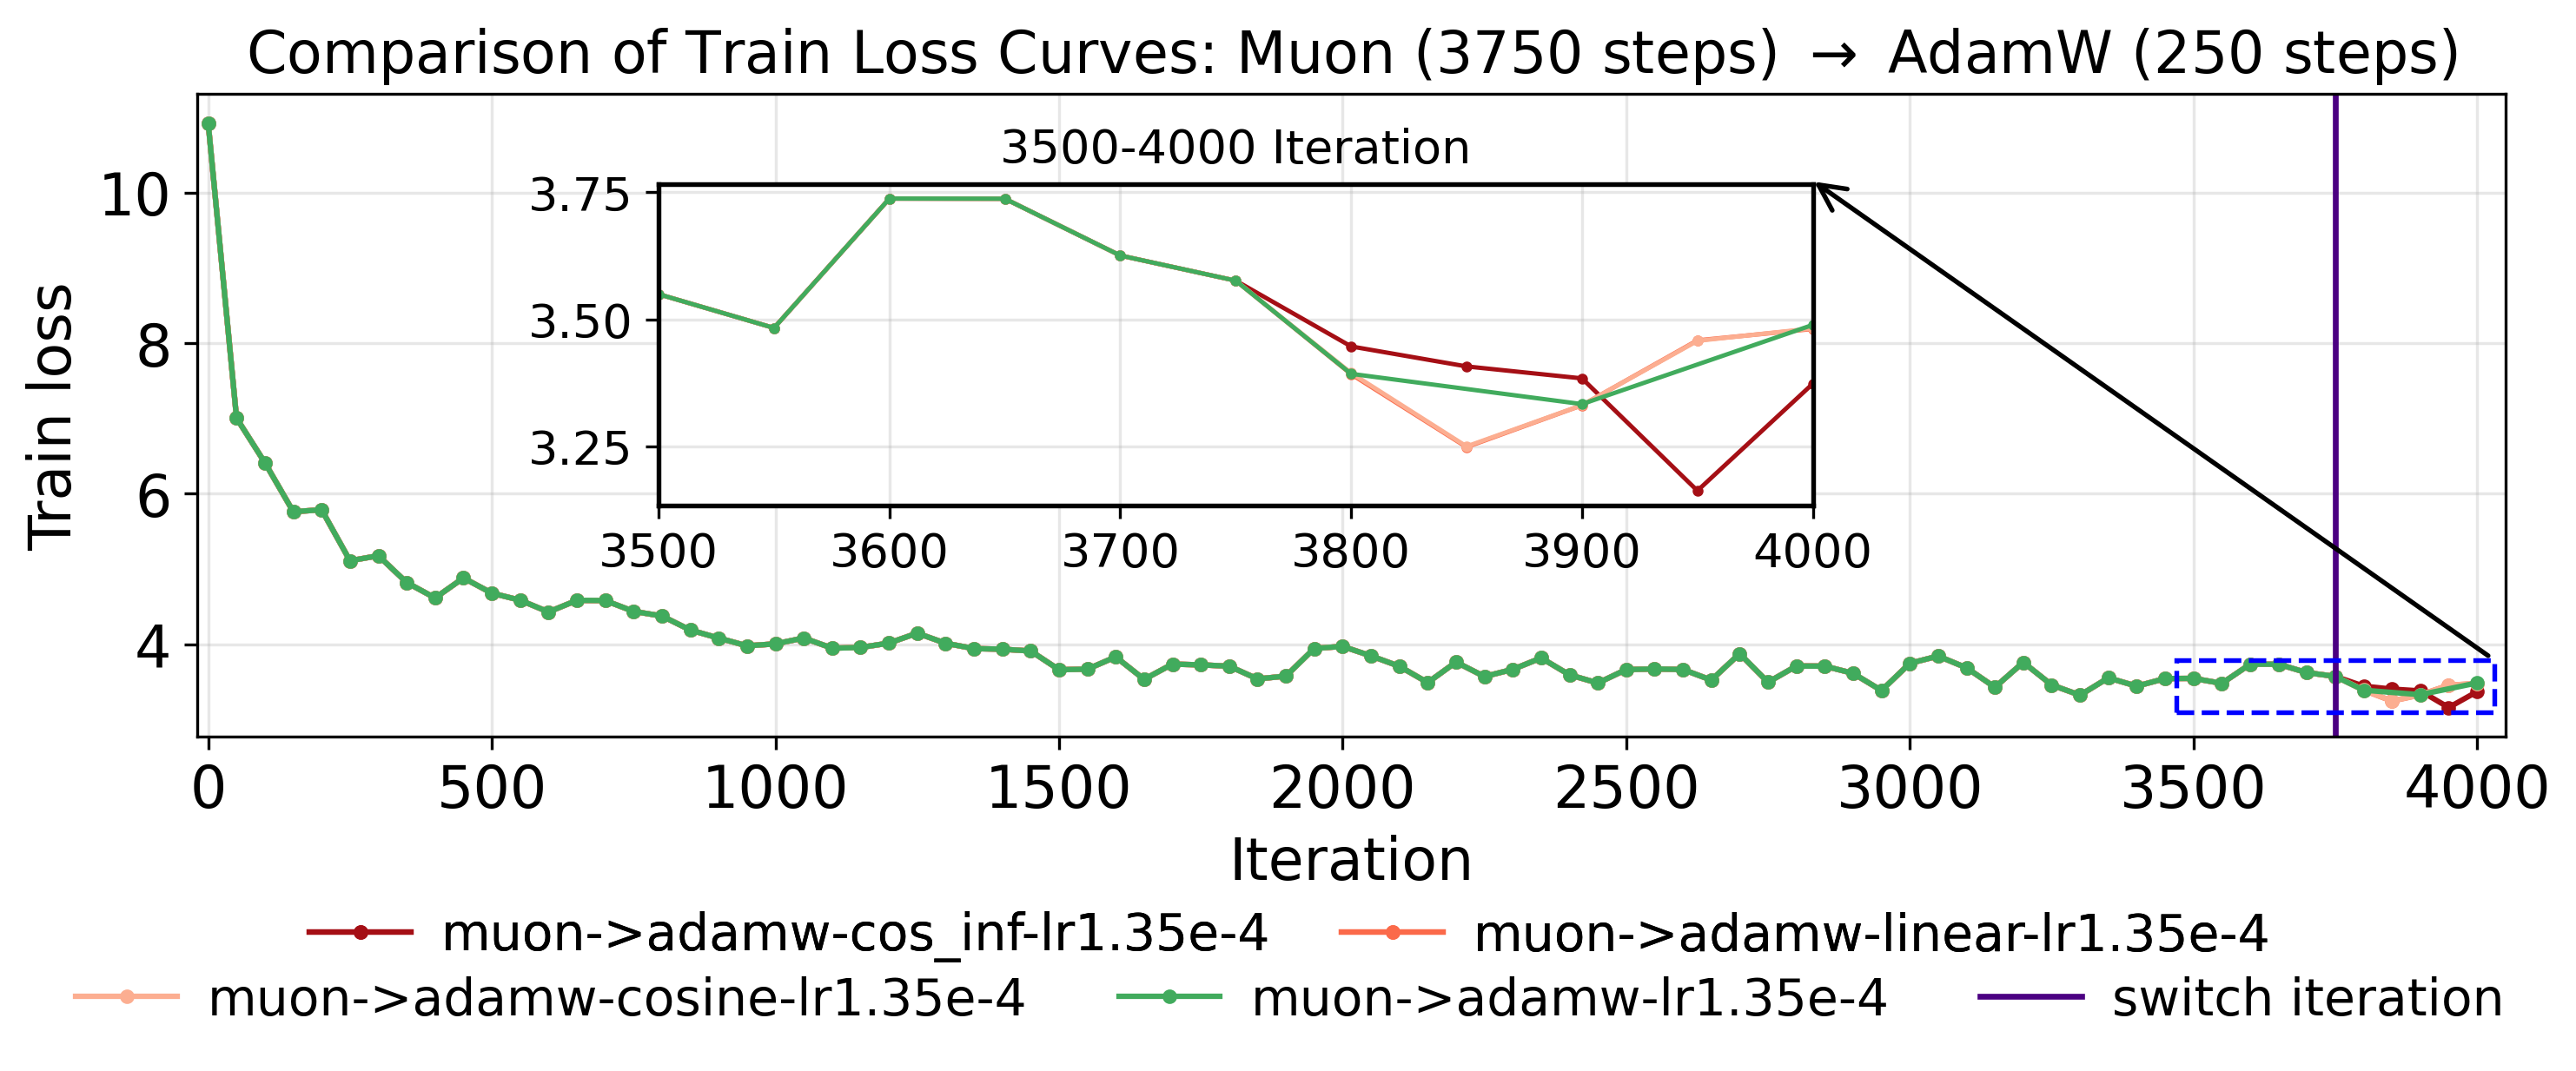

Saved figure to: llm_pretrain_lr_scheduler_muon3750adamw250_train.pdf


In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon->adamw-cos_inf-lr1.35e-4", "muon->adamw-linear-lr1.35e-4", "muon->adamw-cosine-lr1.35e-4", "muon->adamw-lr1.35e-4"]:
    x, y = get_hybrid_curve(df, x_col, "muon3750", col_map_train[name], switch_iter, "train", keep="post")
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Train Loss Curves: Muon (3750 steps) $\to$ AdamW (250 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Train loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.20, 0.36, 0.50, 0.50])
for name in ["muon->adamw-cos_inf-lr1.35e-4", "muon->adamw-linear-lr1.35e-4", "muon->adamw-cosine-lr1.35e-4", "muon->adamw-lr1.35e-4"]:
    x, y = get_hybrid_curve(df, x_col, "muon3750", col_map_train[name], switch_iter, "train", keep="post")
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_hybrid_curve(df, x_col, "muon3750", col_map_train["muon->adamw-cos_inf-lr1.35e-4"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon3750", col_map_train["muon->adamw-linear-lr1.35e-4"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon3750", col_map_train["muon->adamw-cosine-lr1.35e-4"], switch_iter, "train", keep="post"),
    get_hybrid_curve(df, x_col, "muon3750", col_map_train["muon->adamw-lr1.35e-4"], switch_iter, "train", keep="post"),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(0.996, 1.02),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon->adamw-cos_inf-lr1.35e-4", "muon->adamw-linear-lr1.35e-4"]
row2 = ["muon->adamw-cosine-lr1.35e-4", "muon->adamw-lr1.35e-4", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon3750adamw250_train.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon3750adamw250_train.pdf")
plt.close()

### Experiment5 result of val loss curves: Muon (3750 steps) $\to$ AdamW (250 steps)

In [26]:
csv_path = "llm_pretrain_lr_scheduler/3750muon+250adamw-val.csv"
df = pd.read_csv(csv_path)
#print(df.columns)  # different from the former two cases
x_col = "iter"
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
muon3750_series = df[[x_col, col_map_val["muon3750"]]].dropna()
if muon3750_series.empty:
    raise ValueError("Column 'muon3750 - val/loss' has no data; cannot determine switch iteration.")
switch_iter = int(muon3750_series[x_col].max())

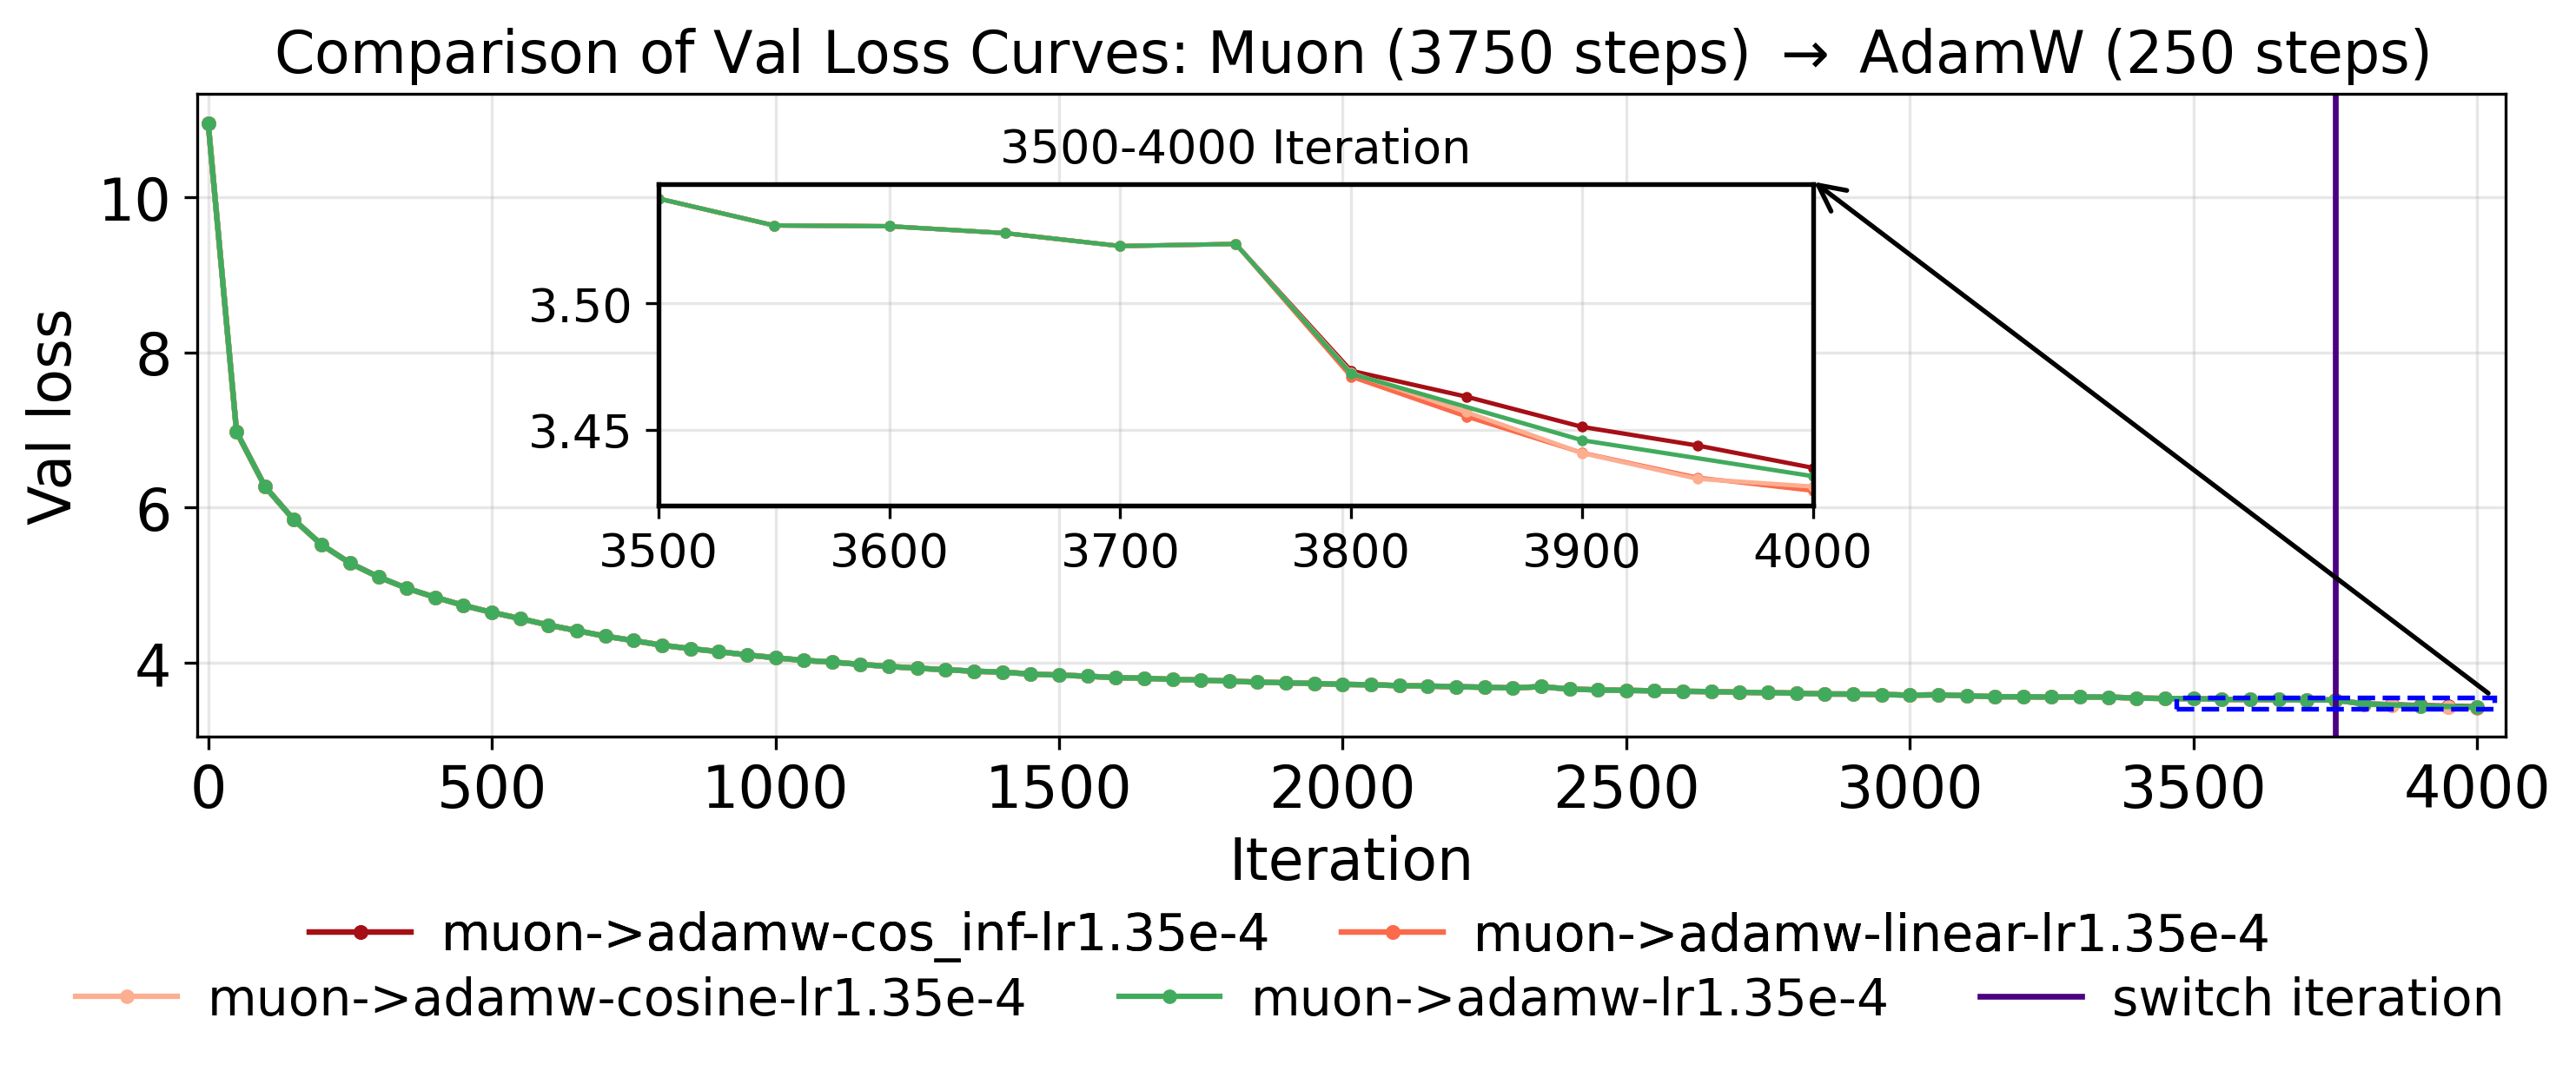

Saved figure to: llm_pretrain_lr_scheduler_muon3750adamw250_val.pdf


In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in ["muon->adamw-cos_inf-lr1.35e-4", "muon->adamw-linear-lr1.35e-4", "muon->adamw-cosine-lr1.35e-4", "muon->adamw-lr1.35e-4"]:
    x, y = get_hybrid_curve(df, x_col, "muon3750", col_map_val[name], switch_iter, "val", keep="post")
    ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=name, color=colors[name])
ax.axvline(switch_iter, color=switch_color, linewidth=1.6, linestyle="-", label="switch iteration")
ax.set_title(rf"Comparison of Val Loss Curves: Muon (3750 steps) $\to$ AdamW (250 steps)", fontsize=16)
ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel("Val loss", fontsize=16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, alpha=0.3)
max_iter = int(df[x_col].max())
ax.set_xlim(-20.0, float(max_iter)+50.0)
zoom_x0 = max_iter - 500
zoom_x1 = max_iter
axins = ax.inset_axes([0.20, 0.36, 0.50, 0.50])
for name in ["muon->adamw-cos_inf-lr1.35e-4", "muon->adamw-linear-lr1.35e-4", "muon->adamw-cosine-lr1.35e-4", "muon->adamw-lr1.35e-4"]:
    x, y = get_hybrid_curve(df, x_col, "muon3750", col_map_val[name], switch_iter, "val", keep="post")
    plot_on(axins, name, x, y, zoom_x0, zoom_x1)
axins.set_title(f"{zoom_x0}-{zoom_x1} Iteration", fontsize=13)
axins.tick_params(axis="both", labelsize=13)
axins.grid(True, alpha=0.3)
axins.set_xlim(zoom_x0, zoom_x1)
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.3)
all_inset_vals = []
for x, y in [
    get_hybrid_curve(df, x_col, "muon3750", col_map_val["muon->adamw-cos_inf-lr1.35e-4"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon3750", col_map_val["muon->adamw-linear-lr1.35e-4"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon3750", col_map_val["muon->adamw-cosine-lr1.35e-4"], switch_iter, "val", keep="post"),
    get_hybrid_curve(df, x_col, "muon3750", col_map_val["muon->adamw-lr1.35e-4"], switch_iter, "val", keep="post"),
]:
    m = (x >= zoom_x0) & (x <= zoom_x1)
    all_inset_vals.append(y[m])
vals = np.concatenate([v for v in all_inset_vals if v.size > 0])
vals = vals[np.isfinite(vals)]
y_min, y_max = vals.min(), vals.max()
margin = (y_max - y_min) * 0.08 if y_max > y_min else 1e-6
zoom_y0, zoom_y1 = y_min - margin, y_max + margin
rect_x0, rect_x1 = zoom_x0 - 30, zoom_x1 + 30
rect_y0, rect_y1 = zoom_y0 - 0.25 * margin, zoom_y1 + 0.25 * margin
rect = Rectangle((rect_x0, rect_y0), rect_x1 - rect_x0, rect_y1 - rect_y0, 
                 fill=False, edgecolor="blue", linewidth=1.3, linestyle="--", zorder=20)
ax.add_patch(rect)
arrow = ConnectionPatch(
    xyA=(rect_x1, rect_y1),         # start point in main axes data coords
    coordsA=ax.transData,
    xyB=(0.996, 1.02),               # end point in inset axes (axes fraction coords)
    coordsB=axins.transAxes, axesA=ax, axesB=axins,
    arrowstyle="->", mutation_scale=18, linewidth=1.3, color="black", shrinkA=2, shrinkB=2, clip_on=False,)
fig.add_artist(arrow)
fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
handles, labels = ax.get_legend_handles_labels()
hmap = dict(zip(labels, handles))
row1 = ["muon->adamw-cos_inf-lr1.35e-4", "muon->adamw-linear-lr1.35e-4"]
row2 = ["muon->adamw-cosine-lr1.35e-4", "muon->adamw-lr1.35e-4", "switch iteration"]
leg1 = fig.legend([hmap[l] for l in row1], row1, loc="lower center", ncol=len(row1), frameon=False,
                  fontsize=14, bbox_to_anchor=(0.5, 0.02), columnspacing=1.4, handletextpad=0.6,)
fig.add_artist(leg1)  # IMPORTANT: keep the first legend when adding the second one
fig.legend([hmap[l] for l in row2], row2, loc="lower center", ncol=len(row2), frameon=False,
           fontsize=14, bbox_to_anchor=(0.5, -0.04), columnspacing=1.8, handletextpad=0.6,)
plt.show()
fig.savefig("llm_pretrain_lr_scheduler_muon3750adamw250_val.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: llm_pretrain_lr_scheduler_muon3750adamw250_val.pdf")
plt.close()